# Speculative Decoding Experiment: Qwen3 4B Target + Qwen3 0.6B Draft

**Phases 1-8**: Data preparation -> Baseline -> Draft Grid A -> Draft Grid B -> Quality/Error Analysis -> Synthesis/Visualization -> ACSD runs -> ACSD evaluation summary

Internal config/result keys use plain `gridA` / `gridB` labels for the two Qwen3-0.6B draft sweeps. Both sweeps use the same real Qwen3-0.6B draft model; `gridB` is a second (compatibility) sweep, not a different model size.

| Config | Draft | k | Regime |
|--------|-------|---|--------|
| Baseline x 2 | Qwen3-4B target only | - | det / stoch |
| Grid A x 6 | Qwen3-0.6B draft | {4,8,16} | det / stoch |
| Grid B x 6 | Qwen3-0.6B draft (second sweep) | {4,8,16} | det / stoch |
| ACSD x N | Qwen3-0.6B primary/rescue draft | adaptive {4,8,16} | det / stoch |

**Total runs:** 2 baselines + 12 AR speculative + ACSD configurations


In [1]:
import importlib
import os
import sys
import time
from datetime import datetime, timedelta
from pathlib import Path

# Ensure src/ is on the path (local execution).
cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd.parent.parent]
project_root = None
for c in candidates:
    if (c / "src").exists() and (c / "experiment.ipynb").exists():
        project_root = c
        break
if project_root is None:
    project_root = cwd

SRC_DIR = str(project_root / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

# Force offline-only model usage from local cache.
os.environ["SPECDEC_HF_OFFLINE_FIRST"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

# -- Qwen3 stack lock (env-level; survives importlib.reload(config)) --------
# src/config.py resolves TARGET_MODEL_ID / DRAFT_MODELS / RESULTS_DIR /
# quantization from these SPECDEC_* env vars at import time.
# runtime.ensure_target_model() calls importlib.reload(config) before
# loading, which re-executes config.py from disk and would otherwise
# resurrect the legacy 7B defaults and the shared repo-root results path.
# With the env vars pinned below, EVERY (re)load of config re-derives the
# Qwen3-4B target / Qwen3-0.6B draft stack and this notebook's own result
# folders, no matter which cell triggers the reload.
EXPECTED_NOTEBOOK_FOLDER = "Review_RTX4090"
_nb_dir = Path.cwd().resolve()
assert _nb_dir.name == EXPECTED_NOTEBOOK_FOLDER, (
    f"This notebook must run with its own folder as cwd; cwd={_nb_dir}"
)
os.environ["SPECDEC_TARGET_MODEL_ID"] = "Qwen/Qwen3-4B"
os.environ["SPECDEC_DRAFT_MODEL_ID"] = "Qwen/Qwen3-0.6B"
os.environ["SPECDEC_ACSD_PRIMARY_DRAFT"] = "0.6B"
os.environ["SPECDEC_ACSD_RESCUE_DRAFT"] = "0.6B"
os.environ["SPECDEC_TARGET_QUANT"] = "fp16"
os.environ["SPECDEC_DRAFT_QUANT"] = "fp16"
os.environ["SPECDEC_RESULTS_DIR"] = str(_nb_dir / "results")
os.environ["SPECDEC_STABILITY_DIR"] = str(_nb_dir / "results" / "stability")
os.environ["SPECDEC_FIGURES_DIR"] = str(_nb_dir / "figures")
os.environ["SPECDEC_DRIFTER_CHECKPOINT_DIR"] = str(_nb_dir / "results" / "drifter_ckpt")

# Core imports with explicit reload so notebook tests always use latest src/ fixes.
import torch
import pandas as pd
from tqdm.auto import tqdm

import config as config_module
import baseline as baseline_module
import speculative as speculative_module
import acsd as acsd_module
import runtime as runtime_module
import utils as utils_module

# -- Backend performance flags (fast attention + pinned single-GPU load) ----
# Wrap quantization.get_quant_kwargs (shared src/ stays untouched) so every
# model load in baseline.load_target_model / speculative.load_draft_model /
# speculative.load_model_on_device picks up:
#   * attn_implementation="flash_attention_2" when the flash-attn package is
#     installed, otherwise PyTorch SDPA (fused flash / mem-efficient kernels)
#   * fp16 via the non-deprecated `dtype` key (replaces `torch_dtype`)
#   * device_map={"": 0} so accelerate can never shard fp16 weights across
#     GPUs or offload layers to CPU (the device-to-host choking failure mode)
# Module reloads of baseline/speculative re-bind from this patched module, so
# the wrapper survives runtime.ensure_target_model()'s internal reloads.
import quantization as quantization_module
quantization_module = importlib.reload(quantization_module)

from importlib.util import find_spec as _find_spec
_FAST_ATTN_IMPL = "flash_attention_2" if _find_spec("flash_attn") is not None else "sdpa"
_original_get_quant_kwargs = quantization_module.get_quant_kwargs


def _fast_get_quant_kwargs(mode=None):
    kwargs, resolved = _original_get_quant_kwargs(mode)
    kwargs = dict(kwargs)
    kwargs.setdefault("attn_implementation", _FAST_ATTN_IMPL)
    if "quantization_config" not in kwargs:
        kwargs.pop("torch_dtype", None)
        kwargs.setdefault("dtype", torch.float16)
        if torch.cuda.is_available():
            kwargs["device_map"] = {"": 0}
    return kwargs, resolved


quantization_module.get_quant_kwargs = _fast_get_quant_kwargs
print(
    "Fast backend loading kwargs installed: "
    f"attn_implementation={_FAST_ATTN_IMPL}, dtype=float16, device_map={{'': 0}}"
)

config_module = importlib.reload(config_module)
utils_module = importlib.reload(utils_module)
baseline_module = importlib.reload(baseline_module)
speculative_module = importlib.reload(speculative_module)
acsd_module = importlib.reload(acsd_module)
runtime_module = importlib.reload(runtime_module)

from config import (
    TARGET_MODEL_ID, DRAFT_MODELS, DATASETS, REGIMES,
    DRAFT_LENGTHS, RESULTS_DIR, STABILITY_DIR, FIGURES_DIR,
    SEED, STABILITY_SEEDS, MANIFESTS_DIR, ACSD_EVAL,
    GPU_TRY_TORCH_COMPILE, GPU_TRY_CUDA_GRAPHS, GPU_REQUIRE_CUDA_GRAPHS,
    GPU_USE_SEPARATE_STREAMS, GPU_PREALLOCATE_STEP_BUFFERS, GPU_USE_STABLE_STEP_SHAPES,
    TARGET_QUANT, DRAFT_QUANT,
    )
from utils import set_seed, get_env_info, write_csv

# Print environment + runtime decode config so notebook tests record the active path.
env = get_env_info()
for k, v in env.items():
    print(f"{k}: {v}")
print("Hugging Face mode: offline-only (local cache)")
print(f"Draft lengths: {DRAFT_LENGTHS}")
print(f"ACSD k choices: {ACSD_EVAL['k_choices']} (base={ACSD_EVAL['base_k']})")
print(f"Quantization: target={TARGET_QUANT}, draft={DRAFT_QUANT}")
print(
    "GPU decode flags: "
    f"compile={GPU_TRY_TORCH_COMPILE}, cuda_graphs={GPU_TRY_CUDA_GRAPHS}, require_graphs={GPU_REQUIRE_CUDA_GRAPHS}, "
    f"streams={GPU_USE_SEPARATE_STREAMS}, buffers={GPU_PREALLOCATE_STEP_BUFFERS}, "
    f"stable_shapes={GPU_USE_STABLE_STEP_SHAPES}"
)

REVIEW_SPEC_FILE_LABELS = {
    "gridA": "qwen3_0.6B",
    "gridB": "qwen3_0.6B_alias",
    "0.6B": "qwen3_0.6B",
}
REVIEW_VISIBLE_DRAFT_LABELS = {
    "gridA": "0.6B",
    "gridB": "0.6B",
    "0.6B": "0.6B",
}


def review_spec_csv_stem(draft_label: str) -> str:
    return f"spec_{REVIEW_SPEC_FILE_LABELS.get(draft_label, draft_label)}"



def review_spec_csv_path(draft_label: str, k: int, regime_name: str) -> Path:
    regime_short = "det" if regime_name == "deterministic" else "stoch"
    return RESULTS_DIR / f"{review_spec_csv_stem(draft_label)}_k{k}_{regime_short}.csv"



def review_load_spec_results(draft_label: str) -> dict[str, list[dict]]:
    results = {}
    for k_val in DRAFT_LENGTHS:
        for regime_name in REGIMES:
            csv_path = review_spec_csv_path(draft_label, k_val, regime_name)
            if not csv_path.exists():
                continue
            rows = pd.read_csv(csv_path).to_dict(orient="records")
            if rows:
                results[f"{draft_label}_k{k_val}_{regime_name}"] = rows
    return results



def install_notebook_progress_helpers():
    helper_version = 6
    if globals().get("_NOTEBOOK_PROGRESS_INSTALLED_VERSION") == helper_version:
        return

    def _short_regime(regime_name: str) -> str:
        return "det" if regime_name == "deterministic" else "stoch"

    def _eta_clock(elapsed_s: float, done_n: int, total_n: int) -> tuple[float, str]:
        if done_n <= 0 or total_n <= done_n:
            return 0.0, "--:--:--"
        remaining_s = max((elapsed_s / done_n) * (total_n - done_n), 0.0)
        eta_ts = datetime.now() + timedelta(seconds=remaining_s)
        return remaining_s, eta_ts.strftime("%H:%M:%S")

    def notebook_run_baseline(
        data: dict[str, list[dict]],
        regime_name: str,
        model=None,
        tokenizer=None,
    ) -> list[dict]:
        regime = REGIMES[regime_name]
        if model is None or tokenizer is None:
            model, tokenizer = baseline_module.load_target_model()

        results = []
        total = sum(len(v) for v in data.values())
        done = 0
        label = f"base {_short_regime(regime_name)}"
        bar = tqdm(
            total=total,
            desc=label,
            dynamic_ncols=True,
            leave=True,
            mininterval=0.5,
            bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]",
        )
        started_at = time.perf_counter()

        try:
            for task_name, samples in data.items():
                max_new_tokens = DATASETS[task_name]["max_new_tokens"]
                task_total = len(samples)
                for task_idx, sample in enumerate(samples, start=1):
                    bar.set_postfix_str(f"task={task_name} {task_idx}/{task_total}")
                    set_seed(SEED)

                    sample_started_at = time.perf_counter()
                    out = baseline_module.run_baseline_sample(
                        model,
                        tokenizer,
                        sample["prompt"],
                        max_new_tokens,
                        regime.temperature,
                        regime.top_p,
                    )
                    sample_elapsed = time.perf_counter() - sample_started_at

                    row = {
                        "sample_id": sample["sample_id"],
                        "task": task_name,
                        "regime": regime_name,
                        **out,
                    }
                    results.append(row)

                    done += 1
                    elapsed = time.perf_counter() - started_at
                    avg_sample_s = elapsed / done if done else 0.0
                    remaining_s, eta_clock = _eta_clock(elapsed, done, total)
                    bar.update(1)
                    bar.set_postfix_str(
                        f"task={task_name} {task_idx}/{task_total} | last={sample_elapsed:.1f}s | avg={avg_sample_s:.1f}s | rem={remaining_s/60:.1f}m | eta={eta_clock}"
                    )
        finally:
            bar.close()

        RESULTS_DIR.mkdir(parents=True, exist_ok=True)
        csv_path = RESULTS_DIR / f"baseline_{regime_name}.csv"
        write_csv(csv_path, results)
        print(f"Saved -> {csv_path}")
        return results

    def notebook_run_speculative_grid(
        data: dict[str, list[dict]],
        draft_label: str,
        k: int,
        regime_name: str,
        target_model=None,
        target_tokenizer=None,
        draft_model=None,
        draft_tokenizer=None,
        seed: int = SEED,
        progress_callback=None,
    ) -> list[dict]:
        regime = REGIMES[regime_name]
        visible_draft_label = REVIEW_VISIBLE_DRAFT_LABELS.get(draft_label, draft_label)
        if target_model is None:
            target_model, target_tokenizer = baseline_module.load_target_model()
        if draft_model is None:
            draft_model, draft_tokenizer = speculative_module.load_draft_model(draft_label)

        results = []
        total = sum(len(v) for v in data.values())
        done = 0
        regime_short = _short_regime(regime_name)
        label = f"spec {visible_draft_label} k={k} {regime_short}"
        bar = tqdm(
            total=total,
            desc=label,
            dynamic_ncols=True,
            leave=True,
            mininterval=0.5,
            bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]",
        )
        started_at = time.perf_counter()

        try:
            for task_name, samples in data.items():
                max_new_tokens = DATASETS[task_name]["max_new_tokens"]
                task_total = len(samples)
                for task_idx, sample in enumerate(samples, start=1):
                    bar.set_postfix_str(f"task={task_name} {task_idx}/{task_total}")
                    set_seed(seed)

                    sample_started_at = time.perf_counter()
                    out = speculative_module.speculative_decode_sample(
                        target_model,
                        draft_model,
                        target_tokenizer,
                        sample["prompt"],
                        max_new_tokens,
                        k,
                        regime.temperature,
                        regime.top_p,
                    )
                    sample_elapsed = time.perf_counter() - sample_started_at

                    row = {
                        "sample_id": sample["sample_id"],
                        "task": task_name,
                        "draft": visible_draft_label,
                        "draft_config_label": draft_label,
                        "k": k,
                        "regime": regime_name,
                        "seed": seed,
                        **{key: val for key, val in out.items() if key != "verify_log"},
                    }
                    results.append(row)

                    done += 1
                    elapsed = time.perf_counter() - started_at
                    avg_sample_s = elapsed / done if done else 0.0
                    remaining_s, eta_clock = _eta_clock(elapsed, done, total)
                    bar.update(1)
                    if progress_callback is not None:
                        progress_callback({
                            "draft_label": visible_draft_label,
                            "k": k,
                            "regime_name": regime_name,
                            "task_name": task_name,
                            "task_idx": task_idx,
                            "task_total": task_total,
                            "done": done,
                            "total": total,
                            "sample_elapsed_s": sample_elapsed,
                            "avg_sample_s": avg_sample_s,
                            "remaining_s": remaining_s,
                            "eta_clock": eta_clock,
                        })
                    bar.set_postfix_str(
                        f"task={task_name} {task_idx}/{task_total} | last={sample_elapsed:.1f}s | avg={avg_sample_s:.1f}s | rem={remaining_s/60:.1f}m | eta={eta_clock}"
                    )
        finally:
            bar.close()

        RESULTS_DIR.mkdir(parents=True, exist_ok=True)
        csv_path = review_spec_csv_path(draft_label, k, regime_name)
        write_csv(csv_path, results)
        print(f"Saved -> {csv_path}")
        return results

    globals()["notebook_run_baseline"] = notebook_run_baseline
    globals()["notebook_run_speculative_grid"] = notebook_run_speculative_grid
    globals()["run_baseline"] = notebook_run_baseline
    globals()["run_speculative_grid"] = notebook_run_speculative_grid
    globals()["review_spec_csv_stem"] = review_spec_csv_stem
    globals()["review_spec_csv_path"] = review_spec_csv_path
    globals()["review_load_spec_results"] = review_load_spec_results

    baseline_module.run_baseline = notebook_run_baseline
    speculative_module.run_speculative_grid = notebook_run_speculative_grid

    globals()["_NOTEBOOK_PROGRESS_INSTALLED"] = True
    globals()["_NOTEBOOK_PROGRESS_INSTALLED_VERSION"] = helper_version
    print("Notebook progress helpers installed (v6)")


install_notebook_progress_helpers()


Fast backend loading kwargs installed: attn_implementation=sdpa, dtype=float16, device_map={'': 0}
python: 
torch: 2.11.0+cu128
cuda_available: True
cuda_version: 12.8
gpu_name: NVIDIA GeForce RTX 4090
device: cuda
transformers: 5.5.4
Hugging Face mode: offline-only (local cache)
Draft lengths: [4, 8, 16]
ACSD k choices: (3, 4, 5) (base=4)
Quantization: target=fp16, draft=fp16
GPU decode flags: compile=False, cuda_graphs=True, require_graphs=False, streams=True, buffers=True, stable_shapes=True
Notebook progress helpers installed (v6)


In [2]:
import importlib
import os
import sys

# NOTE (path-resolution fix): previously this pointed at
# project_root / "Review" / "results", but project_root resolves to the
# shared repo root, and the REAL seed=42 fixed-k grid CSVs from past runs
# actually live directly under THIS notebook's own folder (e.g.
# .../Review_RTX4090/results/spec_qwen3_0.6B_k4_det.csv), not under a nested
# "Review/results/" subfolder (that nested folder only holds unrelated
# mock-data artifacts from a different notebook, new_experiments.ipynb).
review_root = Path.cwd().resolve()
review_results_dir = review_root / "results"

# Explicit hard guarantee (no silent fallback to the shared repo-root
# ./results/, which holds a different, legacy run): assert this
# notebook's own folder name appears in the resolved RESULTS_DIR path.
assert "Review_RTX4090" in str(review_results_dir), (
    f"RESULTS_DIR resolved to {review_results_dir}, which is NOT inside "
    "this notebook's own 'Review_RTX4090' folder. Refusing to silently use "
    "a parent/shared results directory."
)
assert str(review_results_dir) == os.environ.get("SPECDEC_RESULTS_DIR"), (
    "SPECDEC_RESULTS_DIR env lock does not match this notebook's results folder. "
    "Run Cell 1 first."
)
print(f"RESULTS_DIR hard-scoped to this notebook's own folder: {review_results_dir}")
review_figures_dir = review_root / "figures"
review_stability_dir = review_results_dir / "stability"
review_drifter_dir = review_results_dir / "drifter_ckpt"

qwen3_target_model_id = "Qwen/Qwen3-4B"
qwen3_draft_model_id = "Qwen/Qwen3-0.6B"

# NOTE (data-integrity / Qwen3-standardization): src/config.py is a SHARED
# file used by other experiments in this repo and must not be edited from
# this notebook. Cell 1 pins the SPECDEC_* env vars (model IDs, results
# dirs, quantization) that config.py reads at import time, so ANY
# importlib.reload(config) -- including the one inside
# runtime.ensure_target_model() -- re-derives the Qwen3 stack instead of
# the legacy 7B defaults. The in-memory assignments below are a second,
# redundant guard, and cover STABILITY_SEEDS, which config.py does not
# read from the environment.
os.environ["SPECDEC_HF_OFFLINE_FIRST"] = "1"
if os.environ.get("SPECDEC_TARGET_MODEL_ID") != qwen3_target_model_id:
    raise RuntimeError("Qwen3 env lock is missing. Run Cell 1 first.")

config_module = sys.modules.get("config")
if config_module is None:
    import config as config_module
config_module = importlib.reload(config_module)

config_module.TARGET_MODEL_ID = qwen3_target_model_id
config_module.DRAFT_MODELS = {
    "0.6B": qwen3_draft_model_id,  # single native Qwen3 label; legacy alias keys removed
}
config_module.RESULTS_DIR = review_results_dir
config_module.STABILITY_DIR = review_stability_dir
config_module.FIGURES_DIR = review_figures_dir
config_module.DRIFTER_CHECKPOINT_DIR = review_drifter_dir
config_module.TARGET_QUANT = "fp16"
config_module.DRAFT_QUANT = "fp16"

# Phase 3 (multi-seed optimization): seed=42 is already comprehensively
# evaluated by the primary fixed-k grid above, so the stability re-run in
# Phase 4b below only needs the two remaining seeds.
config_module.STABILITY_SEEDS = [123, 999]

if hasattr(config_module, "ACSD_EVAL"):
    config_module.ACSD_EVAL = dict(config_module.ACSD_EVAL)
    config_module.ACSD_EVAL["primary_draft"] = "0.6B"
    config_module.ACSD_EVAL["rescue_draft"] = "0.6B"

for _d in (review_results_dir, review_figures_dir, review_stability_dir, review_drifter_dir):
    _d.mkdir(parents=True, exist_ok=True)

# Reload dependent modules so their `from config import ...` bindings pick up
# the patched (Qwen3) values above.
for module_name in ("runtime", "baseline", "speculative", "acsd", "hf_assistant", "drift_speculative", "utils"):
    module = sys.modules.get(module_name)
    if module is not None:
        importlib.reload(module)

globals().update({
    "TARGET_MODEL_ID": config_module.TARGET_MODEL_ID,
    "DRAFT_MODELS": config_module.DRAFT_MODELS,
    "RESULTS_DIR": config_module.RESULTS_DIR,
    "STABILITY_DIR": config_module.STABILITY_DIR,
    "FIGURES_DIR": config_module.FIGURES_DIR,
    "TARGET_QUANT": config_module.TARGET_QUANT,
    "DRAFT_QUANT": config_module.DRAFT_QUANT,
    "STABILITY_SEEDS": config_module.STABILITY_SEEDS,
})
if hasattr(config_module, "ACSD_EVAL"):
    globals()["ACSD_EVAL"] = config_module.ACSD_EVAL

print("Patched config in-memory for this notebook's kernel (config.py on disk is untouched):")
print(f"  TARGET_MODEL_ID = {config_module.TARGET_MODEL_ID}")
print(f"  DRAFT_MODELS    = {config_module.DRAFT_MODELS}")
print(f"  RESULTS_DIR     = {config_module.RESULTS_DIR}")
print(f"  ACSD_EVAL primary/rescue draft = {config_module.ACSD_EVAL['primary_draft']}/{config_module.ACSD_EVAL['rescue_draft']}")
print(f"  STABILITY_SEEDS = {config_module.STABILITY_SEEDS}  (seed=42 skipped; already covered by the fixed-k grid above)")


# --- Phase 3 (deep-search refinement): robust grid-CSV cache helpers -------
# Different past runs saved Grid A/B CSVs under slightly different naming
# conventions (e.g. "spec_qwen3_0.6B_k4_det.csv" vs "spec_0.6B_k4_det.csv").
# Rather than assume one convention, we list every known real candidate per
# grid and auto-detect which one this folder actually uses by checking what
# exists on disk. This replaces the old alias-key system with
# clear "gridA"/"gridB" naming, and replaces reliance on the shared
# runtime.ensure_spec_results() (which hardcodes the raw label into the
# filename with no alias remapping, so it cannot find files saved under a
# different convention -- e.g. it would look for a raw-label filename, which
# does not exist in either review folder).
REVIEW_GRID_STEM_CANDIDATES = {
    "gridA": ["qwen3_0.6B", "0.6B"],
    "gridB": ["qwen3_0.6B_alias", "0.6B_gridB"],
}


def _review_detect_canonical_stem(grid_key: str) -> str:
    for stem in REVIEW_GRID_STEM_CANDIDATES.get(grid_key, [grid_key]):
        if (RESULTS_DIR / f"spec_{stem}_k4_det.csv").exists():
            return stem
    return REVIEW_GRID_STEM_CANDIDATES.get(grid_key, [grid_key])[0]


REVIEW_GRID_CANONICAL_STEM = {
    grid_key: _review_detect_canonical_stem(grid_key) for grid_key in REVIEW_GRID_STEM_CANDIDATES
}


def review_spec_csv_path(grid_key: str, k_val: int, regime_name: str) -> Path:
    """Canonical (save) path for a grid's CSV -- the stem this folder already uses."""
    regime_short = "det" if regime_name == "deterministic" else "stoch"
    stem = REVIEW_GRID_CANONICAL_STEM.get(grid_key, grid_key)
    return RESULTS_DIR / f"spec_{stem}_k{k_val}_{regime_short}.csv"


def review_find_existing_spec_csv(grid_key: str, k_val: int, regime_name: str):
    """First existing real CSV path among all known candidate stems, or None."""
    regime_short = "det" if regime_name == "deterministic" else "stoch"
    for stem in REVIEW_GRID_STEM_CANDIDATES.get(grid_key, [grid_key]):
        candidate = RESULTS_DIR / f"spec_{stem}_k{k_val}_{regime_short}.csv"
        if candidate.exists():
            return candidate
    return None


def review_load_spec_results(grid_key: str) -> dict:
    """Load every cached (k, regime) result for a grid from disk, trying all
    known real filename candidates. Missing combos are simply absent from the
    returned dict -- callers should treat that as 'needs real execution'."""
    results = {}
    for k_val in DRAFT_LENGTHS:
        for regime_name in REGIMES:
            existing = review_find_existing_spec_csv(grid_key, k_val, regime_name)
            if existing is not None:
                rows = pd.read_csv(existing).to_dict(orient="records")
                if rows:
                    results[f"{grid_key}_k{k_val}_{regime_name}"] = rows
    return results


def review_grid_fully_cached(grid_key: str) -> bool:
    """True iff every (k, regime) combo for this grid already has a real
    cached CSV on disk -- i.e. safe to skip model loading for this phase."""
    return all(
        review_find_existing_spec_csv(grid_key, k_val, regime_name) is not None
        for k_val in DRAFT_LENGTHS
        for regime_name in REGIMES
    )


globals()["review_spec_csv_path"] = review_spec_csv_path
globals()["review_find_existing_spec_csv"] = review_find_existing_spec_csv
globals()["review_load_spec_results"] = review_load_spec_results
globals()["review_grid_fully_cached"] = review_grid_fully_cached

print(
    "Grid CSV cache detection: "
    f"gridA -> stem='{REVIEW_GRID_CANONICAL_STEM['gridA']}' (fully cached={review_grid_fully_cached('gridA')}), "
    f"gridB -> stem='{REVIEW_GRID_CANONICAL_STEM['gridB']}' (fully cached={review_grid_fully_cached('gridB')})"
)


RESULTS_DIR hard-scoped to this notebook's own folder: C:\Working\speculative-decoding-main_v10\speculative-decoding-main\Review_RTX4090\results
Patched config in-memory for this notebook's kernel (config.py on disk is untouched):
  TARGET_MODEL_ID = Qwen/Qwen3-4B
  DRAFT_MODELS    = {'0.6B': 'Qwen/Qwen3-0.6B'}
  RESULTS_DIR     = C:\Working\speculative-decoding-main_v10\speculative-decoding-main\Review_RTX4090\results
  ACSD_EVAL primary/rescue draft = 0.6B/0.6B
  STABILITY_SEEDS = [123, 999]  (seed=42 skipped; already covered by the fixed-k grid above)
Grid CSV cache detection: gridA -> stem='qwen3_0.6B' (fully cached=True), gridB -> stem='qwen3_0.6B_alias' (fully cached=False)


## Phase 1 — Data Preparation & Reproducibility Lock

Load GSM8K (300), MMLU (5×100), CNN/DailyMail (200) with `seed=42`, freeze manifests.

In [3]:
# Hugging Face offline-only mode (force local cache usage).
import os

os.environ["SPECDEC_HF_OFFLINE_FIRST"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
print("Offline-only mode enabled: local Hugging Face cache only.")


Offline-only mode enabled: local Hugging Face cache only.


In [4]:
from data_loader import load_all_datasets, freeze_manifests, save_full_data, load_from_manifests

# Check if manifests already exist (skip download if so)
manifests_exist = all(
    (MANIFESTS_DIR / f"{t}_data.json").exists()
    for t in ["gsm8k", "mmlu", "cnndm"]
)

if manifests_exist:
    print("Manifests found — loading from disk (no re-download)")
    data = load_from_manifests()
else:
    print("Downloading and sampling datasets…")
    data = load_all_datasets()
    freeze_manifests(data)
    save_full_data(data)

# Quick sanity check
for task, samples in data.items():
    print(f"  {task}: {len(samples)} samples, first id: {samples[0]['sample_id']}")

Manifests found — loading from disk (no re-download)
  [gsm8k] loaded 300 samples from manifest
  [mmlu] loaded 500 samples from manifest
  [cnndm] loaded 200 samples from manifest
  gsm8k: 300 samples, first id: gsm8k_2
  mmlu: 500 samples, first id: mmlu_abstract_algebra_0
  cnndm: 200 samples, first id: cnndm_3


### Verify Tokenizer Compatibility

In [5]:
import importlib
import os

import httpx
import hf_utils as hf_utils_module
import data_loader as data_loader_module
from huggingface_hub import set_client_factory

# Use Clash proxy and force online lookup for tokenizer files when they are not cached locally.
proxy_url = "http://127.0.0.1:7890"
os.environ["HTTP_PROXY"] = proxy_url
os.environ["HTTPS_PROXY"] = proxy_url
os.environ["http_proxy"] = proxy_url
os.environ["https_proxy"] = proxy_url

os.environ["SPECDEC_HF_OFFLINE_FIRST"] = "0"
os.environ.pop("HF_HUB_OFFLINE", None)
os.environ.pop("TRANSFORMERS_OFFLINE", None)
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

set_client_factory(
    lambda: httpx.Client(
        proxy=proxy_url,
        timeout=60.0,
        follow_redirects=True,
        trust_env=True,
    )
)

hf_utils_module = importlib.reload(hf_utils_module)
data_loader_module = importlib.reload(data_loader_module)
verify_tokenizer_compatibility = data_loader_module.verify_tokenizer_compatibility

print(f"HF proxy: {proxy_url}")
print("Hugging Face mode: online via proxy for tokenizer compatibility check")
print(f"hf_offline_first={hf_utils_module.hf_offline_first()}")
print(f"hf_model_kwargs={hf_utils_module.hf_model_kwargs()}")

compatible = verify_tokenizer_compatibility()
assert compatible, "Tokenizer mismatch; cannot proceed with speculative decoding."


HF proxy: http://127.0.0.1:7890
Hugging Face mode: online via proxy for tokenizer compatibility check
hf_offline_first=False
hf_model_kwargs={'trust_remote_code': True, 'local_files_only': False, 'proxies': {'http': 'http://127.0.0.1:7890', 'https': 'http://127.0.0.1:7890'}}


c:\ProgramData\anaconda3\envs\py12-dl\Lib\site-packages\huggingface_hub\utils\_validators.py:180: UserWarning: The `proxies` argument is ignored in `hf_hub_download`. To set up proxies, use the HTTP_PROXY / HTTPS_PROXY environment variables or configure the `httpx.Client` manually using `huggingface_hub.set_client_factory`. See https://www.python-httpx.org/advanced/proxies/ for more details.
  warnings.warn(


  Qwen/Qwen3-4B: vocab_size = 151643
  Qwen/Qwen3-0.6B: vocab_size = 151643
  Qwen/Qwen3-0.6B: vocab_size = 151643
  Qwen/Qwen3-0.6B: vocab_size = 151643
  ✓ All tokenizers share vocab_size = 151643


## Phase 2 — Baseline Benchmarking

Run Qwen3-4B autoregressive decoding on all 1,000 samples in both regimes.

In [6]:
import os
import sys
import importlib
from pathlib import Path

# Ensure src/ is on the path (local execution).
os.environ["SPECDEC_HF_OFFLINE_FIRST"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

cwd = Path.cwd().resolve()
def _find_project_root(start):
    for c in [start, *start.parents]:
        if (c / "src" / "baseline.py").exists():
            return c
    return start

project_root = _find_project_root(cwd)
SRC_DIR = str(project_root / "src")
if not (project_root / "src" / "baseline.py").exists():
    raise ModuleNotFoundError(
        f"Could not find src/baseline.py from cwd={cwd}."
    )
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

# Force-refresh modules to avoid stale target-model config in long-lived kernels.
import config as config_module
import baseline as baseline_module
import runtime as runtime_module
config_module = importlib.reload(config_module)
baseline_module = importlib.reload(baseline_module)
runtime_module = importlib.reload(runtime_module)

from runtime import bootstrap_notebook, ensure_data, ensure_target_model
from baseline import run_baseline
from config import TARGET_MODEL_ID

bootstrap_notebook()
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

data = ensure_data(globals())
target_model, target_tokenizer = ensure_target_model(globals())

loaded_target = str(getattr(target_model, "name_or_path", ""))
print(f"Configured target model: {TARGET_MODEL_ID}")
print(f"Loaded target model: {loaded_target}")
assert TARGET_MODEL_ID == "Qwen/Qwen3-4B", f"Unexpected TARGET_MODEL_ID: {TARGET_MODEL_ID}"
assert loaded_target == TARGET_MODEL_ID, f"Target mismatch: loaded={loaded_target}, expected={TARGET_MODEL_ID}"

if "baseline_det" not in globals() and (RESULTS_DIR / "baseline_deterministic.csv").exists():
    baseline_det = pd.read_csv(RESULTS_DIR / "baseline_deterministic.csv").to_dict(orient="records")
if "baseline_stoch" not in globals() and (RESULTS_DIR / "baseline_stochastic.csv").exists():
    baseline_stoch = pd.read_csv(RESULTS_DIR / "baseline_stochastic.csv").to_dict(orient="records")


Loading target model: Qwen/Qwen3-4B (quant=fp16 -> fp16, offline_first=True)


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Configured target model: Qwen/Qwen3-4B
Loaded target model: Qwen/Qwen3-4B


In [7]:
# --- Deterministic baseline ---


print("=" * 60)
print("Baseline: DETERMINISTIC regime")
print("=" * 60)
if globals().get("baseline_det"):
    print("Using existing deterministic baseline from memory/disk")
else:
    baseline_det = notebook_run_baseline(data, "deterministic", target_model, target_tokenizer)



Baseline: DETERMINISTIC regime


base det:   0%|          | 0/1000 [00:00<?, ?it/s]

Saved -> C:\Working\speculative-decoding-main_v10\speculative-decoding-main\Review\results\baseline_deterministic.csv


In [8]:
# --- Stochastic baseline ---
print("=" * 60)
print("Baseline: STOCHASTIC regime")
print("=" * 60)
if globals().get("baseline_stoch"):
    print("Using existing stochastic baseline from memory/disk")
else:
    baseline_stoch = notebook_run_baseline(data, "stochastic", target_model, target_tokenizer)



Baseline: STOCHASTIC regime


base stoch:   0%|          | 0/1000 [00:00<?, ?it/s]

Saved -> C:\Working\speculative-decoding-main_v10\speculative-decoding-main\Review\results\baseline_stochastic.csv


In [9]:
# --- Evaluate baseline quality ---
from evaluate import evaluate_results

print("\nBaseline quality — Deterministic:")
base_quality_det = evaluate_results(baseline_det, data)

print("\nBaseline quality — Stochastic:")
base_quality_stoch = evaluate_results(baseline_stoch, data)


Baseline quality — Deterministic:
  gsm8k (exact_match): 35.33%  (n=300)
  mmlu (letter_match): 64.40%  (n=500)
  cnndm (rouge_l): 19.58%  (n=200)

Baseline quality — Stochastic:
  gsm8k (exact_match): 36.00%  (n=300)
  mmlu (letter_match): 64.00%  (n=500)
  cnndm (rouge_l): 19.34%  (n=200)


In [10]:
# --- Quick latency summary ---
from metrics import compute_latency_metrics

print("\nBaseline latency — Deterministic:")
base_lat_det = compute_latency_metrics(baseline_det)
for k, v in base_lat_det.items():
    print(f"  {k}: {v}")

print("\nBaseline latency — Stochastic:")
base_lat_stoch = compute_latency_metrics(baseline_stoch)
for k, v in base_lat_stoch.items():
    print(f"  {k}: {v}")


Baseline latency — Deterministic:
  T_mean_s: 13.9546
  T_median_s: 9.6314
  R_tok_mean: 8.96
  TTFT_mean_ms: 274.04
  TPOT_mean_ms: 109.79
  total_tokens: 124800
  n_samples: 1000

Baseline latency — Stochastic:
  T_mean_s: 13.9354
  T_median_s: 9.6962
  R_tok_mean: 8.87
  TTFT_mean_ms: 274.58
  TPOT_mean_ms: 110.92
  total_tokens: 124800
  n_samples: 1000


## Phase 2.5 — Dual-GPU Qwen3 Pilot (First 200 Samples)

Load the Qwen3-4B target on `cuda:0` and a second Qwen3 model instance as draft on `cuda:1`, then run speculative decoding on the first 200 samples (`k=4`) for both regimes. Output CSV format matches existing speculative result files for unified analysis.

In [ ]:
import os
import sys
from pathlib import Path

import time
from datetime import datetime, timedelta

import torch
from tqdm.auto import tqdm

# Ensure src/ is importable even when this cell is run independently.
os.environ["SPECDEC_HF_OFFLINE_FIRST"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

cwd = Path.cwd().resolve()
project_root = next((p for p in [cwd, *cwd.parents] if (p / "src" / "runtime.py").exists()), cwd)
SRC_DIR = str(project_root / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

from runtime import bootstrap_notebook, ensure_data, ensure_dual_3b_results
from config import TARGET_MODEL_ID, RESULTS_DIR

bootstrap_notebook()

if not torch.cuda.is_available() or torch.cuda.device_count() < 2:
    raise RuntimeError("Dual-GPU run requires at least 2 CUDA devices: cuda:0 and cuda:1")

data = ensure_data(globals())

# Show exactly how many rows are taken per task from the global first-200 slice.
remaining = 200
subset_breakdown = {}
for task_name, samples in data.items():
    if remaining <= 0:
        break
    take_n = min(len(samples), remaining)
    if take_n > 0:
        subset_breakdown[task_name] = take_n
        remaining -= take_n

print(f"Target model id: {TARGET_MODEL_ID}")
print(f"CUDA devices: {torch.cuda.device_count()}")
print(f"Subset breakdown (first 200 total): {subset_breakdown}")
print("Live compare: showing two progress bars (draft on cuda:1, target verify on cuda:0) with separate ETA")

spec_results_7b_dual = ensure_dual_3b_results(
    globals(),
    k=4,
    max_samples=200,
    target_device="cuda:0",
    draft_device="cuda:1",
    regimes=("deterministic", "stochastic"),
    draft_label="7B_dual",
    show_realtime_progress=True,
    force_rerun=True,
 )

print("Saved CSV files:")
for regime_name in ("deterministic", "stochastic"):
    short = "det" if regime_name == "deterministic" else "stoch"
    print(f"  - {RESULTS_DIR / f'spec_4B_dual_k4_{short}.csv'}")

print(f"Completed dual-4B configs: {list(spec_results_7b_dual.keys())}")

Target model id: Qwen/Qwen3-4B
CUDA devices: 2
Subset breakdown (first 200 total): {'gsm8k': 200}
Live compare: showing two progress bars (draft on cuda:1, target verify on cuda:0) with separate ETA
Loading model: Qwen/Qwen3-4B (device=cuda:0, quant=fp16 -> fp16, offline_first=True)


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading model: Qwen/Qwen3-4B (device=cuda:1, quant=fp16 -> fp16, offline_first=True)


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

draft 7B_dual cuda:1:   0%|          | 0/200 [00:00<?, ?it/s]

target verify cuda:0:   0%|          | 0/200 [00:00<?, ?it/s]

  Saved -> C:\Working\speculative-decoding-main_v10\speculative-decoding-main\Review\results\spec_7B_dual_k4_det.csv
  Verify logs -> C:\Working\speculative-decoding-main_v10\speculative-decoding-main\Review\results\verify_logs\spec_7B_dual_k4_det_seed42.json


draft 7B_dual cuda:1:   0%|          | 0/200 [00:00<?, ?it/s]

target verify cuda:0:   0%|          | 0/200 [00:00<?, ?it/s]

  Saved -> C:\Working\speculative-decoding-main_v10\speculative-decoding-main\Review\results\spec_7B_dual_k4_stoch.csv
  Verify logs -> C:\Working\speculative-decoding-main_v10\speculative-decoding-main\Review\results\verify_logs\spec_7B_dual_k4_stoch_seed42.json
Saved CSV files:
  - C:\Working\speculative-decoding-main_v10\speculative-decoding-main\Review\results\spec_7B_dual_k4_det.csv
  - C:\Working\speculative-decoding-main_v10\speculative-decoding-main\Review\results\spec_7B_dual_k4_stoch.csv
Completed dual-7B configs: ['7B_dual_k4_deterministic', '7B_dual_k4_stochastic']


## Phase 3.1 -- Full Grid Run (k={4,8,16} x {det,stoch}) + Baseline-Format CSV Export

In [ ]:
import os
import sys
from pathlib import Path

import torch

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd.parent.parent]
project_root = None
for c in candidates:
    if (c / "src").exists() and (c / "experiment.ipynb").exists():
        project_root = c
        break
if project_root is None:
    project_root = cwd

SRC_DIR = str(project_root / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

os.environ["SPECDEC_HF_OFFLINE_FIRST"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

from runtime import bootstrap_notebook, ensure_data, ensure_baseline_results
from speculative import run_speculative_grid, load_model_on_device
from config import TARGET_MODEL_ID, DRAFT_MODELS, TARGET_QUANT, DRAFT_QUANT

bootstrap_notebook()
if "install_notebook_progress_helpers" in globals():
    install_notebook_progress_helpers()
if "review_load_spec_results" not in globals():
    raise RuntimeError("Review result-file helpers are not initialized. Run Cell 2, then rerun this cell.")

data = ensure_data(globals())
ensure_baseline_results(globals())
spec_results_gridA = review_load_spec_results("gridA")
VISIBLE_DRAFT_LABEL_GRIDA = "0.6B"

# Phase 3 (cache-bypass): only load target/draft models onto GPU if at least
# one (k, regime) combination in Grid A is still missing a real cached CSV.
if review_grid_fully_cached("gridA"):
    print("Target Grid A CSV artifacts detected for all (k, regime) combinations. "
          "Skipping active evaluation loops to save compute time.")
    target_model = globals().get("target_model")
    target_tokenizer = globals().get("target_tokenizer")
    draft_gridA_model = globals().get("draft_gridA_model")
    draft_gridA_tokenizer = globals().get("draft_gridA_tokenizer")
else:
    # Force single-GPU placement to avoid cross-GPU transfer overhead.
    FORCE_SINGLE_GPU = True
    RUN_DEVICE = "cuda:0"

    if FORCE_SINGLE_GPU and not torch.cuda.is_available():
        raise RuntimeError("FORCE_SINGLE_GPU=True but CUDA is unavailable")

    if FORCE_SINGLE_GPU:
        target_model, target_tokenizer = load_model_on_device(
            TARGET_MODEL_ID, RUN_DEVICE, TARGET_QUANT
        )
        draft_gridA_model, draft_gridA_tokenizer = load_model_on_device(
            DRAFT_MODELS["0.6B"], RUN_DEVICE, DRAFT_QUANT
        )
    else:
        from runtime import ensure_target_model, ensure_draft_model
        target_model, target_tokenizer = ensure_target_model(globals())
        draft_gridA_model, draft_gridA_tokenizer = ensure_draft_model(globals(), "0.6B")

    globals()["target_model"] = target_model
    globals()["target_tokenizer"] = target_tokenizer
    globals()["draft_gridA_model"] = draft_gridA_model
    globals()["draft_gridA_tokenizer"] = draft_gridA_tokenizer

    loaded_target = str(getattr(target_model, "name_or_path", ""))
    print(f"Configured target model: {TARGET_MODEL_ID}")
    print(f"Loaded target model: {loaded_target}")
    assert loaded_target == TARGET_MODEL_ID, f"Target mismatch: loaded={loaded_target}, expected={TARGET_MODEL_ID}"

    def _model_device_summary(model, name):
        hf_map = getattr(model, "hf_device_map", None)
        if isinstance(hf_map, dict):
            devices = sorted({str(v) for v in hf_map.values()})
            has_cpu = any(str(v).startswith("cpu") for v in devices)
            has_disk = any(str(v).startswith("disk") for v in devices)
        else:
            devices = [str(next(model.parameters()).device)]
            has_cpu = False
            has_disk = False
        print(f"{name} devices: {devices}")
        if has_cpu or has_disk:
            print(f"WARNING: {name} has CPU/disk offload; speculative latency can degrade heavily.")
        return devices

    target_devices = _model_device_summary(target_model, "target")
    draft_devices = _model_device_summary(draft_gridA_model, f"draft_{VISIBLE_DRAFT_LABEL_GRIDA}")

    same_single_cuda = (
        len(target_devices) == 1
        and len(draft_devices) == 1
        and target_devices[0].startswith("cuda")
        and draft_devices[0].startswith("cuda")
        and target_devices[0] == draft_devices[0]
        )
    print(f"same_single_cuda={same_single_cuda}")

    if FORCE_SINGLE_GPU and not same_single_cuda:
        raise RuntimeError(
            "FORCE_SINGLE_GPU is enabled, but target and draft are not on the same single CUDA device."
        )


In [ ]:
from config import DRAFT_LENGTHS, REGIMES

spec_results_gridA = globals().get("spec_results_gridA", {})
spec_grid_runner = globals().get("notebook_run_speculative_grid")
if spec_grid_runner is None:
    raise RuntimeError("Notebook progress runner is not initialized. Run Cell 2, then rerun Cell 14 and this cell.")

# Optional debug knobs for CUDA assert localization on Windows.
DEBUG_SPEC_FAIL_FAST = True
DEBUG_MAX_SAMPLES_PER_TASK = None  # e.g. 8 for quick reproduction, None for full run.
VISIBLE_DRAFT_LABEL_GRIDA = "0.6B"

if review_grid_fully_cached("gridA"):
    print("Target Grid A CSV artifacts detected. Skipping active evaluation loop to save compute time.")
else:
    if DEBUG_SPEC_FAIL_FAST:
        import os
        os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
        print("Debug mode: CUDA_LAUNCH_BLOCKING=1")

    # Use the full dataset (1000 samples) for the Qwen3-0.6B grid runs.
    data_full_gridA = data
    if DEBUG_MAX_SAMPLES_PER_TASK is not None:
        data_full_gridA = {k: v[:DEBUG_MAX_SAMPLES_PER_TASK] for k, v in data.items()}

    total_samples_gridA = sum(len(v) for v in data_full_gridA.values())
    breakdown_gridA = {k: len(v) for k, v in data_full_gridA.items()}
    print(f"Using dataset for Qwen3 {VISIBLE_DRAFT_LABEL_GRIDA} grid: {total_samples_gridA} samples")
    print(f"Dataset breakdown: {breakdown_gridA}")

    planned_configs_gridA = [
        (k_val, regime_name)
        for k_val in DRAFT_LENGTHS
        for regime_name in REGIMES
        if not globals().get("spec_results_gridA", {}).get(f"gridA_k{k_val}_{regime_name}")
    ]
    phase_total_samples_gridA = total_samples_gridA * len(planned_configs_gridA)
    phase_done_samples_gridA = [0]
    phase_started_at_gridA = time.perf_counter()
    phase_bar_gridA = None

    def _phase_eta_text_gridA(done_n: int, total_n: int) -> tuple[float, str]:
        if done_n <= 0 or done_n >= total_n:
            return 0.0, "--:--:--"
        elapsed_s = time.perf_counter() - phase_started_at_gridA
        remaining_s = max((elapsed_s / done_n) * (total_n - done_n), 0.0)
        eta_clock = (datetime.now() + timedelta(seconds=remaining_s)).strftime("%H:%M:%S")
        return remaining_s, eta_clock

    if phase_total_samples_gridA > 0:
        phase_bar_gridA = tqdm(
            total=phase_total_samples_gridA,
            desc=f"phase {VISIBLE_DRAFT_LABEL_GRIDA} samples",
            dynamic_ncols=True,
            leave=True,
            mininterval=0.2,
            bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]",
        )
        print(f"Phase {VISIBLE_DRAFT_LABEL_GRIDA} live progress enabled: {phase_total_samples_gridA} sample runs pending with realtime ETA")
    else:
        print(f"Phase {VISIBLE_DRAFT_LABEL_GRIDA} already complete; no new sample runs scheduled.")

    def _on_sample_gridA(event: dict) -> None:
        if phase_bar_gridA is None:
            return
        phase_done_samples_gridA[0] += 1
        phase_bar_gridA.update(1)
        remaining_s, eta_clock = _phase_eta_text_gridA(phase_done_samples_gridA[0], phase_total_samples_gridA)
        phase_bar_gridA.set_postfix_str(
            f"cfg={VISIBLE_DRAFT_LABEL_GRIDA} k={event['k']} {event['regime_name']} | task={event['task_name']} {event['task_idx']}/{event['task_total']} | last={event['sample_elapsed_s']:.1f}s | rem={remaining_s/60:.1f}m | eta={eta_clock}"
        )

    try:
        for k_val in DRAFT_LENGTHS:
            for regime_name in REGIMES:
                config_key = f"gridA_k{k_val}_{regime_name}"
                if config_key in spec_results_gridA and spec_results_gridA[config_key]:
                    print(f"Skipping existing config: {config_key}")
                    continue

                print(f"{'=' * 60}")
                print(f"Speculative: draft={VISIBLE_DRAFT_LABEL_GRIDA}, k={k_val}, regime={regime_name}, samples={total_samples_gridA}")
                print(f"{'=' * 60}")

                try:
                    results = spec_grid_runner(
                        data_full_gridA, "gridA", k_val, regime_name,
                        target_model, target_tokenizer,
                        draft_gridA_model, draft_gridA_tokenizer,
                        progress_callback=_on_sample_gridA,
                    )
                    spec_results_gridA[config_key] = results
                except Exception as e:
                    print("\n[FAIL] Grid A execution failed")
                    print(f"  config={config_key}")
                    print(f"  type={type(e).__name__}")
                    print(f"  message={e}")
                    raise
    finally:
        if phase_bar_gridA is not None:
            phase_bar_gridA.close()

    globals()["spec_results_gridA"] = spec_results_gridA

print(f"Grid A ready: {len(spec_results_gridA)} configs")


In [ ]:
# --- Grid A: Evaluate quality and compute metrics ---
from metrics import compute_acceptance_metrics, compute_speedup, compute_quality_delta, compute_latency_metrics
from evaluate import evaluate_results

grid_a_summary = []
for config_key, results in spec_results_gridA.items():
    parts = config_key.split("_")  # e.g. 'gridA_k4_deterministic'
    k_val = int(parts[1][1:])
    regime = parts[2]

    baseline_ref = baseline_det if regime == "deterministic" else baseline_stoch
    base_quality_ref = base_quality_det if regime == "deterministic" else base_quality_stoch

    lat = compute_latency_metrics(results)
    acc = compute_acceptance_metrics(results)
    quality = evaluate_results(results, data)
    speedup = compute_speedup(baseline_ref, results)
    delta_q = compute_quality_delta(base_quality_ref, quality)

    df_cfg = pd.DataFrame(results)
    if 'gpu_graph_capture' in df_cfg.columns and not df_cfg.empty:
        graph_mode = str(df_cfg['gpu_graph_capture'].mode().iloc[0])
        graph_capture_rate = float((df_cfg['gpu_graph_capture'] == 'captured').mean())
    else:
        graph_mode = 'n/a'
        graph_capture_rate = 0.0

    print(f"\n{config_key}: S={speedup:.2f}x, alpha={acc['alpha']:.3f}, B_eff={acc['B_eff']:.1f}")
    for task_k, dq in delta_q.items():
        print(f"  {task_k}: {dq:+.2f}pp")

    grid_a_summary.append({
        "config": config_key, "draft": "0.6B", "k": k_val, "regime": regime,
        **lat, **acc, "S": speedup, **quality, **delta_q,
        "gpu_graph_mode": graph_mode,
        "gpu_graph_capture_rate": round(graph_capture_rate, 4),
    })

df_grid_a = pd.DataFrame(grid_a_summary)
df_grid_a


## Phase 3.1 — Full Grid Run (k={4,8,16} x {det,stoch}) + Baseline-Format CSV Export

Explicitly load Qwen3-4B target + Qwen3-0.6B draft, run all 6 Grid A configs on 1000 samples, and export additional CSV files with the same column schema as baseline outputs.

In [ ]:
# Phase 3.1: run full Grid A (k={4,8,16} x {det,stoch}) and export baseline-format CSVs
import os
import sys
from pathlib import Path

import pandas as pd
import torch

# Resolve project root and make src importable for standalone execution.
cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd.parent.parent]
project_root = None
for c in candidates:
    if (c / "src").exists() and (c / "experiment.ipynb").exists():
        project_root = c
        break
if project_root is None:
    project_root = cwd

SRC_DIR = str(project_root / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

os.environ["SPECDEC_HF_OFFLINE_FIRST"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

from runtime import bootstrap_notebook, ensure_data, ensure_baseline_results
from speculative import load_model_on_device
from config import TARGET_MODEL_ID, DRAFT_MODELS, TARGET_QUANT, DRAFT_QUANT, DRAFT_LENGTHS, REGIMES, RESULTS_DIR

bootstrap_notebook()
if "install_notebook_progress_helpers" in globals():
    install_notebook_progress_helpers()

if "notebook_run_speculative_grid" not in globals():
    raise RuntimeError("Notebook speculative runner is not initialized. Run Cell 2 first.")

data = ensure_data(globals())
ensure_baseline_results(globals())

total_samples = sum(len(v) for v in data.values())
print(f"Phase 3.1 dataset size: {total_samples} samples")
if total_samples != 1000:
    print(f"WARNING: expected 1000 samples, got {total_samples}")

spec_results_gridA = globals().get("spec_results_gridA") or review_load_spec_results("gridA")

baseline_like_cols = [
    "sample_id", "task", "regime",
    "latency_s", "ttft_ms", "tpot_ms", "num_tokens", "tokens_per_sec", "output_text",
]

# Phase 3 (cache-bypass): this phase duplicates Grid A's own speculative
# sweep purely to also export a baseline-format CSV per config. If Grid A's
# real results are already cached (from Cell 17/18, or on disk), reuse those
# rows directly instead of loading models and re-running generation.
existing_baselinefmt = {
    (k_val, regime_name): (RESULTS_DIR / f"spec_qwen3_0.6B_k{k_val}_{'det' if regime_name == 'deterministic' else 'stoch'}_baselinefmt.csv").exists()
    for k_val in DRAFT_LENGTHS
    for regime_name in REGIMES
}
phase31_fully_cached = all(existing_baselinefmt.values())

if phase31_fully_cached:
    print("Target Phase 3.1 baseline-format CSV artifacts detected for all (k, regime) combinations. "
          "Skipping active evaluation loop to save compute time.")
    export_manifest = [
        {
            "config_key": f"gridA_k{k_val}_{regime_name}",
            "k": k_val,
            "regime": regime_name,
            "samples": "n/a (loaded from existing cache)",
            "full_csv": str(review_spec_csv_path("gridA", k_val, regime_name)),
            "baseline_format_csv": str(RESULTS_DIR / f"spec_qwen3_0.6B_k{k_val}_{'det' if regime_name == 'deterministic' else 'stoch'}_baselinefmt.csv"),
        }
        for k_val in DRAFT_LENGTHS
        for regime_name in REGIMES
    ]
elif review_grid_fully_cached("gridA"):
    print("Grid A results are fully cached (Cell 17/18). Reusing cached rows to "
          "build the baseline-format export instead of re-running generation.")
    export_manifest = []
    for k_val in DRAFT_LENGTHS:
        for regime_name in REGIMES:
            config_key = f"gridA_k{k_val}_{regime_name}"
            rows = spec_results_gridA.get(config_key, [])

            baseline_like_rows = [{
                "sample_id": r.get("sample_id"),
                "task": r.get("task"),
                "regime": r.get("regime", regime_name),
                "latency_s": r.get("latency_s"),
                "ttft_ms": r.get("ttft_ms"),
                "tpot_ms": r.get("tpot_ms"),
                "num_tokens": r.get("num_tokens"),
                "tokens_per_sec": r.get("tokens_per_sec"),
                "output_text": r.get("output_text"),
            } for r in rows]

            out_short = "det" if regime_name == "deterministic" else "stoch"
            out_baseline_fmt = RESULTS_DIR / f"spec_qwen3_0.6B_k{k_val}_{out_short}_baselinefmt.csv"
            pd.DataFrame(baseline_like_rows, columns=baseline_like_cols).to_csv(out_baseline_fmt, index=False)

            export_manifest.append({
                "config_key": config_key,
                "k": k_val,
                "regime": regime_name,
                "samples": len(rows),
                "full_csv": str(review_spec_csv_path("gridA", k_val, regime_name)),
                "baseline_format_csv": str(out_baseline_fmt),
            })
else:
    # Explicitly load both models for this phase.
    RUN_DEVICE = "cuda:0"
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA is required for this Phase 3.1 full run.")

    target_model, target_tokenizer = load_model_on_device(
        TARGET_MODEL_ID, RUN_DEVICE, TARGET_QUANT
    )
    draft_model, draft_tokenizer = load_model_on_device(
        DRAFT_MODELS["0.6B"], RUN_DEVICE, DRAFT_QUANT
    )

    loaded_target = str(getattr(target_model, "name_or_path", ""))
    loaded_draft = str(getattr(draft_model, "name_or_path", ""))
    expected_draft = DRAFT_MODELS["0.6B"]
    print(f"Configured target model: {TARGET_MODEL_ID}")
    print(f"Loaded target model: {loaded_target}")
    print(f"Configured draft model(0.6B): {expected_draft}")
    print(f"Loaded draft model: {loaded_draft}")
    assert loaded_target == TARGET_MODEL_ID, f"Target mismatch: loaded={loaded_target}, expected={TARGET_MODEL_ID}"
    assert loaded_draft == expected_draft, f"Draft mismatch: loaded={loaded_draft}, expected={expected_draft}"

    spec_grid_runner = globals()["notebook_run_speculative_grid"]

    export_manifest = []
    for k_val in DRAFT_LENGTHS:
        for regime_name in REGIMES:
            config_key = f"gridA_k{k_val}_{regime_name}"
            print("=" * 70)
            print(f"Phase 3.1 run: draft=0.6B, target=4B, k={k_val}, regime={regime_name}, samples={total_samples}")
            print("=" * 70)

            rows = spec_grid_runner(
                data,
                "gridA",
                k_val,
                regime_name,
                target_model,
                target_tokenizer,
                draft_model,
                draft_tokenizer,
            )
            spec_results_gridA[config_key] = rows

            baseline_like_rows = [{
                "sample_id": r.get("sample_id"),
                "task": r.get("task"),
                "regime": r.get("regime", regime_name),
                "latency_s": r.get("latency_s"),
                "ttft_ms": r.get("ttft_ms"),
                "tpot_ms": r.get("tpot_ms"),
                "num_tokens": r.get("num_tokens"),
                "tokens_per_sec": r.get("tokens_per_sec"),
                "output_text": r.get("output_text"),
            } for r in rows]

            out_short = "det" if regime_name == "deterministic" else "stoch"
            out_baseline_fmt = RESULTS_DIR / f"spec_qwen3_0.6B_k{k_val}_{out_short}_baselinefmt.csv"
            pd.DataFrame(baseline_like_rows, columns=baseline_like_cols).to_csv(out_baseline_fmt, index=False)

            export_manifest.append({
                "config_key": config_key,
                "k": k_val,
                "regime": regime_name,
                "samples": len(rows),
                "full_csv": str(review_spec_csv_path("gridA", k_val, regime_name)),
                "baseline_format_csv": str(out_baseline_fmt),
            })

    globals()["spec_results_gridA"] = spec_results_gridA

manifest_df = pd.DataFrame(export_manifest)
manifest_path = RESULTS_DIR / "phase3_1_fullrun_export_manifest.csv"
manifest_df.to_csv(manifest_path, index=False)

print("Phase 3.1 full run complete.")
print(f"Export manifest -> {manifest_path}")
display(manifest_df)


## Phase 4 -- Speculative Grid B: Qwen3-0.6B Draft (Second Sweep)

This phase saves results under the `gridB` key, a second sweep of the same real Qwen3-0.6B draft model (kept separate from Grid A for compatibility with the existing analysis/plotting code downstream).

In [ ]:
import os
import sys
from pathlib import Path
import time
from datetime import datetime, timedelta

import torch
from tqdm.auto import tqdm

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd.parent.parent]
project_root = None
for c in candidates:
    if (c / "src").exists() and (c / "experiment.ipynb").exists():
        project_root = c
        break
if project_root is None:
    project_root = cwd

SRC_DIR = str(project_root / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

os.environ["SPECDEC_HF_OFFLINE_FIRST"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import gc
from runtime import bootstrap_notebook, ensure_data, ensure_baseline_results
from speculative import run_speculative_grid, load_model_on_device
from config import TARGET_MODEL_ID, DRAFT_MODELS, TARGET_QUANT, DRAFT_QUANT

bootstrap_notebook()
if "install_notebook_progress_helpers" in globals():
    install_notebook_progress_helpers()
if "review_load_spec_results" not in globals():
    raise RuntimeError("Review result-file helpers are not initialized. Run Cell 2, then rerun this cell.")

data = ensure_data(globals())
ensure_baseline_results(globals())
spec_results_gridA = review_load_spec_results("gridA")
spec_results_gridB = review_load_spec_results("gridB")
VISIBLE_DRAFT_LABEL_GRIDB = "0.6B"

# Phase 3 (cache-bypass): only load target/draft models onto GPU if at least
# one (k, regime) combination in Grid B is still missing a real cached CSV.
if review_grid_fully_cached("gridB"):
    print("Target Grid B CSV artifacts detected for all (k, regime) combinations. "
          "Skipping active evaluation loops to save compute time.")
    target_model = globals().get("target_model")
    target_tokenizer = globals().get("target_tokenizer")
    draft_gridB_model = globals().get("draft_gridB_model")
    draft_gridB_tokenizer = globals().get("draft_gridB_tokenizer")
else:
    FORCE_SINGLE_GPU = True
    RUN_DEVICE = "cuda:0"

    if FORCE_SINGLE_GPU and not torch.cuda.is_available():
        raise RuntimeError("FORCE_SINGLE_GPU=True but CUDA is unavailable")

    # Release old draft refs before reloading the Grid-B draft sweep.
    for name in ("draft_gridA_model", "draft_gridA_tokenizer", "draft_gridB_model", "draft_gridB_tokenizer"):
        if name in globals():
            del globals()[name]
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if FORCE_SINGLE_GPU:
        target_model, target_tokenizer = load_model_on_device(
            TARGET_MODEL_ID, RUN_DEVICE, TARGET_QUANT
        )
        draft_gridB_model, draft_gridB_tokenizer = load_model_on_device(
            DRAFT_MODELS["0.6B"], RUN_DEVICE, DRAFT_QUANT
        )
    else:
        from runtime import ensure_target_model, ensure_draft_model
        target_model, target_tokenizer = ensure_target_model(globals())
        draft_gridB_model, draft_gridB_tokenizer = ensure_draft_model(globals(), "0.6B")

    globals()["target_model"] = target_model
    globals()["target_tokenizer"] = target_tokenizer
    globals()["draft_gridB_model"] = draft_gridB_model
    globals()["draft_gridB_tokenizer"] = draft_gridB_tokenizer

    loaded_target = str(getattr(target_model, "name_or_path", ""))
    print(f"Configured target model: {TARGET_MODEL_ID}")
    print(f"Loaded target model: {loaded_target}")
    assert loaded_target == TARGET_MODEL_ID, f"Target mismatch: loaded={loaded_target}, expected={TARGET_MODEL_ID}"

    def _model_device_summary(model, name):
        hf_map = getattr(model, "hf_device_map", None)
        if isinstance(hf_map, dict):
            devices = sorted({str(v) for v in hf_map.values()})
        else:
            devices = [str(next(model.parameters()).device)]
        print(f"{name} devices: {devices}")
        return devices

    target_devices = _model_device_summary(target_model, "target")
    draft_devices = _model_device_summary(draft_gridB_model, f"draft_{VISIBLE_DRAFT_LABEL_GRIDB}")
    same_single_cuda = (
        len(target_devices) == 1 and len(draft_devices) == 1
        and target_devices[0].startswith("cuda")
        and target_devices[0] == draft_devices[0]
        )
    print(f"same_single_cuda={same_single_cuda}")
    if FORCE_SINGLE_GPU and not same_single_cuda:
        raise RuntimeError("FORCE_SINGLE_GPU is enabled, but target and Grid-B draft are not co-located.")


In [ ]:
from config import DRAFT_LENGTHS, REGIMES

spec_results_gridB = globals().get("spec_results_gridB", {})
spec_grid_runner = globals().get("notebook_run_speculative_grid")
if spec_grid_runner is None:
    raise RuntimeError("Notebook progress runner is not initialized. Run Cell 2, then rerun Cell 19 and this cell.")

VISIBLE_DRAFT_LABEL_GRIDB = "0.6B"

if review_grid_fully_cached("gridB"):
    print("Target Grid B CSV artifacts detected. Skipping active evaluation loop to save compute time.")
else:
    # Use the full dataset (1000 samples) for the Grid-B draft sweep.
    data_full_gridB = data
    total_samples_gridB = sum(len(v) for v in data_full_gridB.values())
    breakdown_gridB = {k: len(v) for k, v in data_full_gridB.items()}
    print(f"Using full dataset for the Qwen3 {VISIBLE_DRAFT_LABEL_GRIDB} Grid-B grid: {total_samples_gridB} samples")
    print(f"Dataset breakdown: {breakdown_gridB}")

    planned_configs_gridB = [
        (k_val, regime_name)
        for k_val in DRAFT_LENGTHS
        for regime_name in REGIMES
        if not globals().get("spec_results_gridB", {}).get(f"gridB_k{k_val}_{regime_name}")
    ]
    phase_total_samples_gridB = total_samples_gridB * len(planned_configs_gridB)
    phase_done_samples_gridB = [0]
    phase_started_at_gridB = time.perf_counter()
    phase_bar_gridB = None

    def _phase_eta_text_gridB(done_n: int, total_n: int) -> tuple[float, str]:
        if done_n <= 0 or done_n >= total_n:
            return 0.0, "--:--:--"
        elapsed_s = time.perf_counter() - phase_started_at_gridB
        remaining_s = max((elapsed_s / done_n) * (total_n - done_n), 0.0)
        eta_clock = (datetime.now() + timedelta(seconds=remaining_s)).strftime("%H:%M:%S")
        return remaining_s, eta_clock

    if phase_total_samples_gridB > 0:
        phase_bar_gridB = tqdm(
            total=phase_total_samples_gridB,
            desc=f"phase {VISIBLE_DRAFT_LABEL_GRIDB} gridB samples",
            dynamic_ncols=True,
            leave=True,
            mininterval=0.2,
            bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]",
        )
        print(f"Phase {VISIBLE_DRAFT_LABEL_GRIDB} Grid-B live progress enabled: {phase_total_samples_gridB} sample runs pending with realtime ETA")
    else:
        print(f"Phase {VISIBLE_DRAFT_LABEL_GRIDB} Grid-B sweep already complete; no new sample runs scheduled.")

    def _on_sample_gridB(event: dict) -> None:
        if phase_bar_gridB is None:
            return
        phase_done_samples_gridB[0] += 1
        phase_bar_gridB.update(1)
        remaining_s, eta_clock = _phase_eta_text_gridB(phase_done_samples_gridB[0], phase_total_samples_gridB)
        phase_bar_gridB.set_postfix_str(
            f"cfg={VISIBLE_DRAFT_LABEL_GRIDB} k={event['k']} {event['regime_name']} | task={event['task_name']} {event['task_idx']}/{event['task_total']} | last={event['sample_elapsed_s']:.1f}s | rem={remaining_s/60:.1f}m | eta={eta_clock}"
        )

    try:
        for k_val in DRAFT_LENGTHS:
            for regime_name in REGIMES:
                config_key = f"gridB_k{k_val}_{regime_name}"
                if config_key in spec_results_gridB and spec_results_gridB[config_key]:
                    print(f"Skipping existing config: {config_key}")
                    continue

                print(f"{'=' * 60}")
                print(f"Speculative: draft={VISIBLE_DRAFT_LABEL_GRIDB}, k={k_val}, regime={regime_name}, samples={total_samples_gridB}")
                print(f"{'=' * 60}")

                results = spec_grid_runner(
                    data_full_gridB, "gridB", k_val, regime_name,
                    target_model, target_tokenizer,
                    draft_gridB_model, draft_gridB_tokenizer,
                    progress_callback=_on_sample_gridB,
                )
                spec_results_gridB[config_key] = results
    finally:
        if phase_bar_gridB is not None:
            phase_bar_gridB.close()

    globals()["spec_results_gridB"] = spec_results_gridB

print(f"Grid B ready: {len(spec_results_gridB)} configs")


In [ ]:
# --- Grid B: Evaluate quality and compute metrics ---
grid_b_summary = []
for config_key, results in spec_results_gridB.items():
    parts = config_key.split("_")
    k_val = int(parts[1][1:])
    regime = parts[2]

    baseline_ref = baseline_det if regime == "deterministic" else baseline_stoch
    base_quality_ref = base_quality_det if regime == "deterministic" else base_quality_stoch

    lat = compute_latency_metrics(results)
    acc = compute_acceptance_metrics(results)
    quality = evaluate_results(results, data)
    speedup = compute_speedup(baseline_ref, results)
    delta_q = compute_quality_delta(base_quality_ref, quality)

    df_cfg = pd.DataFrame(results)
    if 'gpu_graph_capture' in df_cfg.columns and not df_cfg.empty:
        graph_mode = str(df_cfg['gpu_graph_capture'].mode().iloc[0])
        graph_capture_rate = float((df_cfg['gpu_graph_capture'] == 'captured').mean())
    else:
        graph_mode = 'n/a'
        graph_capture_rate = 0.0

    print(f"\n{config_key}: S={speedup:.2f}x, alpha={acc['alpha']:.3f}, B_eff={acc['B_eff']:.1f}")
    for task_k, dq in delta_q.items():
        print(f"  {task_k}: {dq:+.2f}pp")

    grid_b_summary.append({
        "config": config_key, "draft": "0.6B", "k": k_val, "regime": regime,
        **lat, **acc, "S": speedup, **quality, **delta_q,
        "gpu_graph_mode": graph_mode,
        "gpu_graph_capture_rate": round(graph_capture_rate, 4),
    })

df_grid_b = pd.DataFrame(grid_b_summary)
df_grid_b


In [ ]:
# --- Combine all 12 configs into master table ---
import pandas as pd

from evaluate import evaluate_results
from metrics import (
    compute_acceptance_metrics,
    compute_latency_metrics,
    compute_quality_delta,
    compute_speedup,
)

# If per-grid summaries are missing (e.g., this cell is run standalone), reconstruct them from saved spec results.
if "df_grid_a" not in globals() or "df_grid_b" not in globals():
    from runtime import ensure_data, ensure_baseline_results

    data = globals().get("data")
    if data is None:
        data = ensure_data(globals())

    ensure_baseline_results(globals())

    # Ensure baseline quality references exist for quality-delta computation.
    if "base_quality_det" not in globals() or "base_quality_stoch" not in globals():
        base_quality_det = evaluate_results(baseline_det, data)
        base_quality_stoch = evaluate_results(baseline_stoch, data)
        globals()["base_quality_det"] = base_quality_det
        globals()["base_quality_stoch"] = base_quality_stoch

    if "review_load_spec_results" not in globals():
        raise RuntimeError("review_load_spec_results is not initialized. Please run Cell 2 first.")

    spec_results_gridA = globals().get("spec_results_gridA")
    if not spec_results_gridA:
        spec_results_gridA = review_load_spec_results("gridA")
        globals()["spec_results_gridA"] = spec_results_gridA

    spec_results_gridB = globals().get("spec_results_gridB")
    if not spec_results_gridB:
        spec_results_gridB = review_load_spec_results("gridB")
        globals()["spec_results_gridB"] = spec_results_gridB

    def _build_grid_summary(spec_results: dict, visible_draft_label: str) -> pd.DataFrame:
        rows_out = []
        for config_key, rows in spec_results.items():
            if not rows:
                continue

            parts = config_key.split("_")
            if len(parts) < 3:
                continue
            k_val = int(parts[1][1:])
            regime = parts[2]

            baseline_ref = baseline_det if regime == "deterministic" else baseline_stoch
            base_quality_ref = base_quality_det if regime == "deterministic" else base_quality_stoch

            lat = compute_latency_metrics(rows)
            acc = compute_acceptance_metrics(rows)
            quality = evaluate_results(rows, data)
            speedup = compute_speedup(baseline_ref, rows)
            delta_q = compute_quality_delta(base_quality_ref, quality)

            df_cfg = pd.DataFrame(rows)
            if "gpu_graph_capture" in df_cfg.columns and not df_cfg.empty:
                graph_mode = str(df_cfg["gpu_graph_capture"].mode().iloc[0])
                graph_capture_rate = float((df_cfg["gpu_graph_capture"] == "captured").mean())
            else:
                graph_mode = "n/a"
                graph_capture_rate = 0.0

            rows_out.append({
                "config": config_key,
                "draft": visible_draft_label,
                "k": k_val,
                "regime": regime,
                **lat,
                **acc,
                "S": speedup,
                **quality,
                **delta_q,
                "gpu_graph_mode": graph_mode,
                "gpu_graph_capture_rate": round(graph_capture_rate, 4),
            })

        return pd.DataFrame(rows_out)

    if "df_grid_a" not in globals():
        df_grid_a = _build_grid_summary(spec_results_gridA, "0.6B")
        globals()["df_grid_a"] = df_grid_a

    if "df_grid_b" not in globals():
        df_grid_b = _build_grid_summary(spec_results_gridB, "0.6B")
        globals()["df_grid_b"] = df_grid_b

df_all = pd.concat([df_grid_a, df_grid_b], ignore_index=True)
globals()["df_all"] = df_all

print("\nFull 12-config results matrix:")
matrix_cols = [c for c in [
    "config", "draft", "k", "regime", "S", "alpha", "B_eff",
    "T_mean_s", "R_tok_mean", "TTFT_mean_ms", "TPOT_mean_ms",
    "gpu_graph_mode", "gpu_graph_capture_rate",
] if c in df_all.columns]
display(df_all[matrix_cols])

# Save master table
df_all.to_csv(RESULTS_DIR / "all_configs_summary.csv", index=False)
print(f"\nSaved -> {RESULTS_DIR / 'all_configs_summary.csv'}")


### Phase 4b -- Stability Analysis (k=4, both regimes; seeds 123 & 999)

Re-run the established best fixed-policy configuration (Qwen3-0.6B draft, k=4) with seeds {123, 999} only. seed=42 is skipped here: it is already comprehensively evaluated by the primary fixed-k grid above, so re-running it in this stability pass would be redundant. k=8 and k=16 are intentionally not swept in this phase to keep the multi-seed re-run budget focused on the one operating point (k=4) already established as fastest.

In [3]:
import os
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd.parent.parent]
project_root = None
for c in candidates:
    if (c / "src").exists() and (c / "experiment.ipynb").exists():
        project_root = c
        break
if project_root is None:
    project_root = cwd

SRC_DIR = str(project_root / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

os.environ["SPECDEC_HF_OFFLINE_FIRST"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

# -- Qwen3 stack lock (env-level; survives importlib.reload(config)) --------
# src/config.py resolves TARGET_MODEL_ID / DRAFT_MODELS / RESULTS_DIR /
# quantization from these SPECDEC_* env vars at import time.
# runtime.ensure_target_model() calls importlib.reload(config) before
# loading, which re-executes config.py from disk and would otherwise
# resurrect the legacy 7B defaults and the shared repo-root results path.
# With the env vars pinned below, EVERY (re)load of config re-derives the
# Qwen3-4B target / Qwen3-0.6B draft stack and this notebook's own result
# folders, no matter which cell triggers the reload.
EXPECTED_NOTEBOOK_FOLDER = "Review_RTX4090"
_nb_dir = Path.cwd().resolve()
assert _nb_dir.name == EXPECTED_NOTEBOOK_FOLDER, (
    f"This notebook must run with its own folder as cwd; cwd={_nb_dir}"
)
os.environ["SPECDEC_TARGET_MODEL_ID"] = "Qwen/Qwen3-4B"
os.environ["SPECDEC_DRAFT_MODEL_ID"] = "Qwen/Qwen3-0.6B"
os.environ["SPECDEC_ACSD_PRIMARY_DRAFT"] = "0.6B"
os.environ["SPECDEC_ACSD_RESCUE_DRAFT"] = "0.6B"
os.environ["SPECDEC_TARGET_QUANT"] = "fp16"
os.environ["SPECDEC_DRAFT_QUANT"] = "fp16"
os.environ["SPECDEC_RESULTS_DIR"] = str(_nb_dir / "results")
os.environ["SPECDEC_STABILITY_DIR"] = str(_nb_dir / "results" / "stability")
os.environ["SPECDEC_FIGURES_DIR"] = str(_nb_dir / "figures")
os.environ["SPECDEC_DRIFTER_CHECKPOINT_DIR"] = str(_nb_dir / "results" / "drifter_ckpt")

from runtime import bootstrap_notebook, ensure_data, ensure_baseline_results, ensure_df_all
from metrics import compute_speedup_stability
from speculative import run_stability_analysis

bootstrap_notebook()
if "review_load_spec_results" not in globals():
    raise RuntimeError("Review result-file helpers are not initialized. Run Cell 2, then rerun this cell.")

data = ensure_data(globals())
ensure_baseline_results(globals())

# Hard verification: the Phase 4b stack must be the true Qwen3 pair and all
# artifacts must stay inside this notebook's own results folders.
import config as _cfg_check
_loaded_target = str(getattr(globals().get("target_model"), "name_or_path", ""))
print(f"Phase 4b target model:  {_loaded_target}")
print(f"Phase 4b draft model:   {_cfg_check.DRAFT_MODELS['0.6B']}")
print(f"Phase 4b RESULTS_DIR:   {_cfg_check.RESULTS_DIR}")
print(f"Phase 4b STABILITY_DIR: {_cfg_check.STABILITY_DIR}")
assert _loaded_target == "Qwen/Qwen3-4B", (
    f"Rogue target model loaded: {_loaded_target!r} (expected Qwen/Qwen3-4B)"
)
assert _cfg_check.DRAFT_MODELS["0.6B"] == "Qwen/Qwen3-0.6B"
assert EXPECTED_NOTEBOOK_FOLDER in str(_cfg_check.RESULTS_DIR)
assert EXPECTED_NOTEBOOK_FOLDER in str(_cfg_check.STABILITY_DIR)
spec_results_gridA = review_load_spec_results("gridA")
spec_results_gridB = review_load_spec_results("gridB")
if "df_all" not in globals() or df_all.empty:
    df_all = ensure_df_all(globals())


  [gsm8k] loaded 300 samples from manifest
  [mmlu] loaded 500 samples from manifest
  [cnndm] loaded 200 samples from manifest
Loading target model: Qwen/Qwen3-4B (quant=fp16 -> fp16, offline_first=True)


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

  gsm8k (exact_match): 35.33%  (n=300)
  mmlu (letter_match): 64.40%  (n=500)
  cnndm (rouge_l): 19.58%  (n=200)
  gsm8k (exact_match): 36.00%  (n=300)
  mmlu (letter_match): 64.00%  (n=500)
  cnndm (rouge_l): 19.34%  (n=200)
Phase 4b target model:  Qwen/Qwen3-4B
Phase 4b draft model:   Qwen/Qwen3-0.6B
Phase 4b RESULTS_DIR:   C:\Working\speculative-decoding-main_v10\speculative-decoding-main\Review_RTX4090\results
Phase 4b STABILITY_DIR: C:\Working\speculative-decoding-main_v10\speculative-decoding-main\Review_RTX4090\results\stability


In [4]:
# Phase 3 (multi-seed optimization): restrict this stability re-run to the
# single optimal configuration (Qwen3-0.6B draft, k=4) across both regimes,
# instead of a dynamic top-2-by-speedup search. k=8/k=16 are intentionally
# not re-run here to avoid redundant computation and repetitive artifacts --
# k=4 is already established as the best operating point in the fixed-k grid
# above. seed=42 is skipped (STABILITY_SEEDS was patched to [123, 999] in
# Cell 2, since seed=42 is already comprehensively evaluated by the fixed-k
# grid above).
import time
from datetime import datetime, timedelta

from tqdm.auto import tqdm
from metrics import compute_speedup
from speculative import load_draft_model

STABILITY_DRAFT_LABEL = "0.6B"  # native Qwen3 label; these are newly-created seed-123/999 files, no legacy alias needed
STABILITY_K = 4

# seed=42 is intentionally excluded: it is already covered by the fixed-k
# grid above. Only the two remaining stability seeds run here, k=4 only.
STABILITY_RUN_SEEDS = [s for s in list(STABILITY_SEEDS) if s != 42]
assert STABILITY_RUN_SEEDS == [123, 999], (
    f"Phase 4b expects exactly seeds [123, 999]; got {STABILITY_RUN_SEEDS}"
)

top2 = pd.DataFrame([
    {"config": f"{STABILITY_DRAFT_LABEL}_k{STABILITY_K}_deterministic", "draft": STABILITY_DRAFT_LABEL, "k": STABILITY_K, "regime": "deterministic"},
    {"config": f"{STABILITY_DRAFT_LABEL}_k{STABILITY_K}_stochastic", "draft": STABILITY_DRAFT_LABEL, "k": STABILITY_K, "regime": "stochastic"},
])
globals()["top2"] = top2

print("Stability configs (hardcoded to k=4, both regimes; seed=42 skipped):")
display(top2[["config", "draft", "k", "regime"]])

spec_grid_runner = globals().get("notebook_run_speculative_grid")
if spec_grid_runner is None:
    raise RuntimeError("Notebook progress runner is not initialized. Run Cell 2, then rerun this cell.")

def _run_stability_analysis_with_progress(
    data_local: dict[str, list[dict]],
    draft_label_local: str,
    k_local: int,
    regime_local: str,
    target_model_local,
    target_tokenizer_local,
    draft_model_local,
    draft_tokenizer_local,
    seeds: list[int],
) -> list[dict]:
    regime_short = "det" if regime_local == "deterministic" else "stoch"
    all_results_local = []
    total_samples_local = sum(len(v) for v in data_local.values())

    for seed in seeds:
        print(f"\n  Stability run: seed={seed}")
        started_at = time.perf_counter()
        done = [0]

        bar = tqdm(
            total=total_samples_local,
            desc=f"stability seed={seed}",
            dynamic_ncols=True,
            leave=True,
            mininterval=0.2,
            bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]",
        )

        def _on_sample(event: dict) -> None:
            done[0] += 1
            bar.update(1)
            elapsed_s = time.perf_counter() - started_at
            avg_sample_s = elapsed_s / done[0] if done[0] else 0.0
            if done[0] > 0 and done[0] < total_samples_local:
                remaining_s = max((elapsed_s / done[0]) * (total_samples_local - done[0]), 0.0)
                eta_clock = (datetime.now() + timedelta(seconds=remaining_s)).strftime("%H:%M:%S")
            else:
                remaining_s = 0.0
                eta_clock = "--:--:--"
            bar.set_postfix_str(
                f"task={event['task_name']} {event['task_idx']}/{event['task_total']} | "
                f"last={event['sample_elapsed_s']:.1f}s | avg={avg_sample_s:.1f}s | "
                f"rem={remaining_s/60:.1f}m | eta={eta_clock}"
            )

        try:
            rows = spec_grid_runner(
                data_local,
                draft_label_local,
                k_local,
                regime_local,
                target_model_local,
                target_tokenizer_local,
                draft_model_local,
                draft_tokenizer_local,
                seed=seed,
                progress_callback=_on_sample,
            )
        finally:
            bar.close()

        STABILITY_DIR.mkdir(parents=True, exist_ok=True)
        csv_path = STABILITY_DIR / f"spec_{draft_label_local}_k{k_local}_{regime_short}_seed{seed}.csv"
        write_csv(csv_path, rows)
        all_results_local.append({"seed": seed, "results": rows})

    return all_results_local

stability_results = {}

if "target_model" not in globals() or "target_tokenizer" not in globals():
    raise RuntimeError("target_model is not loaded. Run the Phase 4b setup cell above first.")

# Load the Qwen3-0.6B draft ONCE for both regimes (it was previously
# reloaded inside the config loop, doubling load time and VRAM churn).
dm, dt = load_draft_model("0.6B")

# Engine warmup: one short speculative pass per regime primes CUDA kernels,
# the caching allocator, and the verify-path capture logic so the first
# timed iteration of each stability run does not absorb one-off
# initialization stalls.
from speculative import speculative_decode_sample as _warmup_decode
_warmup_prompt = next(iter(data.values()))[0]["prompt"]
for _regime_name, _regime in REGIMES.items():
    _t0 = time.perf_counter()
    _warmup_decode(
        target_model, dm, target_tokenizer,
        _warmup_prompt, 16, STABILITY_K,
        _regime.temperature, _regime.top_p,
    )
    print(f"Warmup [{_regime_name}]: {time.perf_counter() - _t0:.1f}s (16 new tokens, k={STABILITY_K})")

for _, row in top2.iterrows():
    draft_label = row["draft"]
    k_val = int(row["k"])
    regime = row["regime"]
    config_key = row["config"]

    print(f"\n{'=' * 60}")
    print(f"Stability analysis: {config_key}")
    print(f"{'=' * 60}")

    seed_runs = _run_stability_analysis_with_progress(
        data, draft_label, k_val, regime,
        target_model, target_tokenizer, dm, dt,
        list(STABILITY_RUN_SEEDS),
    )

    # Compute speedup per seed
    baseline_ref = baseline_det if regime == "deterministic" else baseline_stoch
    speedups = []
    for sr in seed_runs:
        s = compute_speedup(baseline_ref, sr["results"])
        speedups.append(s)
        print(f"  seed={sr['seed']}: S={s:.4f}")

    sigma = compute_speedup_stability(speedups)
    print(f"  sigma_S = {sigma:.4f}")
    stability_results[config_key] = {"speedups": speedups, "sigma_S": sigma}

print("\nStability analysis complete")


Stability configs (hardcoded to k=4, both regimes; seed=42 skipped):


,config,draft,k,regime
0,0.6B_k4_deterministic,0.6B,4,deterministic
1,0.6B_k4_stochastic,0.6B,4,stochastic


Loading draft model: Qwen/Qwen3-0.6B (quant=fp16 -> fp16, offline_first=True)


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Warmup [deterministic]: 1.3s (16 new tokens, k=4)
Warmup [stochastic]: 1.1s (16 new tokens, k=4)

Stability analysis: 0.6B_k4_deterministic

  Stability run: seed=123


...

spec 0.6B k=4 stoch:   0%|          | 0/1000 [00:00<?, ?it/s]

Saved -> C:\Working\speculative-decoding-main_v10\speculative-decoding-main\Review_RTX4090\results\spec_0.6B_k4_stoch.csv

  Stability run: seed=999


stability seed=999:   0%|          | 0/1000 [00:00<?, ?it/s]

spec 0.6B k=4 stoch:   0%|          | 0/1000 [00:00<?, ?it/s]

Saved -> C:\Working\speculative-decoding-main_v10\speculative-decoding-main\Review_RTX4090\results\spec_0.6B_k4_stoch.csv
  seed=123: S=2.2992
  seed=999: S=2.4169
  sigma_S = 0.0832

Stability analysis complete


## Phase 5 — Quality and Error Analysis

Systematic analysis of disagreement patterns between speculative and baseline outputs, including length buckets, taxonomy, and rejection behavior proxies.

In [ ]:
import os
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd.parent.parent]
project_root = None
for c in candidates:
    if (c / "src").exists() and (c / "experiment.ipynb").exists():
        project_root = c
        break
if project_root is None:
    project_root = cwd

SRC_DIR = str(project_root / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

os.environ["SPECDEC_HF_OFFLINE_FIRST"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

from difflib import SequenceMatcher
import numpy as np
from evaluate import cnndm_rouge_l
from runtime import bootstrap_notebook, ensure_data, ensure_baseline_results

bootstrap_notebook()
if "review_load_spec_results" not in globals():
    raise RuntimeError("Review result-file helpers are not initialized. Run Cell 2, then rerun this cell.")

data = ensure_data(globals())
ensure_baseline_results(globals())
spec_results_gridA = review_load_spec_results("gridA")
spec_results_gridB = review_load_spec_results("gridB")

# Merge all speculative runs
all_spec_results = {**spec_results_gridA, **spec_results_gridB}

# Baseline lookup by regime + sample_id
baseline_lookup = {
    "deterministic": {r["sample_id"]: r for r in baseline_det},
    "stochastic": {r["sample_id"]: r for r in baseline_stoch},
}

rows = []
for config_name, cfg_rows in all_spec_results.items():
    regime = cfg_rows[0]["regime"] if cfg_rows else "deterministic"
    for r in cfg_rows:
        sid = r["sample_id"]
        base = baseline_lookup[regime].get(sid)
        if base is None:
            continue

        pred_text = (r.get("output_text") or "").strip()
        base_text = (base.get("output_text") or "").strip()

        pred_words = len(pred_text.split())
        base_words = len(base_text.split())
        disagree = pred_text != base_text
        sim_ratio = SequenceMatcher(None, pred_text, base_text).ratio()

        if pred_words <= 16:
            length_bucket = "short"
        elif pred_words <= 64:
            length_bucket = "medium"
        else:
            length_bucket = "long"

        rouge_to_base = np.nan
        if r["task"] == "cnndm" and pred_text and base_text:
            rouge_to_base = cnndm_rouge_l(pred_text, base_text)

        rows.append({
            "config": config_name,
            "draft": r["draft"],
            "k": r["k"],
            "regime": regime,
            "task": r["task"],
            "sample_id": sid,
            "disagree": disagree,
            "pred_words": pred_words,
            "base_words": base_words,
            "length_bucket": length_bucket,
            "sim_ratio": sim_ratio,
            "rouge_to_base": rouge_to_base,
            "alpha_sample": (r.get("total_accepted", 0) / r.get("total_proposed", 1)) if r.get("total_proposed", 0) > 0 else np.nan,
        })

df_phase5 = pd.DataFrame(rows)
print(f"Constructed Phase 5 analysis table: {len(df_phase5)} rows")
display(df_phase5.head(10))


In [ ]:
# Disagreement rates by config/task and by output length bucket

df_disagree = df_phase5[df_phase5["disagree"]].copy()

disagree_rate = (
    df_phase5.groupby(["config", "task"], as_index=False)["disagree"]
    .mean()
    .rename(columns={"disagree": "disagreement_rate"})
)

bucket_dist = (
    df_disagree.groupby(["config", "length_bucket"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)
if not bucket_dist.empty:
    bucket_dist["pct_within_config"] = (
        bucket_dist["count"]
        / bucket_dist.groupby("config")["count"].transform("sum")
        * 100
    ).round(2)

print("Disagreement rate by config/task:")
display(disagree_rate.sort_values(["disagreement_rate", "config"], ascending=[False, True]).head(20))

print("\nLength bucket distribution among disagreement cases:")
display(bucket_dist.sort_values(["config", "length_bucket"]))

In [ ]:
# Error taxonomy + rejection clustering proxy

def classify_error(row):
    if not row["disagree"]:
        return "match"

    pred_w = max(row["pred_words"], 1)
    base_w = max(row["base_words"], 1)

    # Truncation: output substantially shorter than baseline output.
    if pred_w < 0.6 * base_w:
        return "truncation"

    # Semantic drift: low lexical similarity and (for CNNDM) low ROUGE-L to baseline output.
    if row["sim_ratio"] < 0.25:
        return "semantic_drift"
    if row["task"] == "cnndm" and not np.isnan(row["rouge_to_base"]) and row["rouge_to_base"] < 0.2:
        return "semantic_drift"

    return "substitution"


df_phase5["error_type"] = df_phase5.apply(classify_error, axis=1)

taxonomy = (
    df_phase5[df_phase5["error_type"] != "match"]
    .groupby(["config", "error_type"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)
if not taxonomy.empty:
    taxonomy["pct_within_config"] = (
        taxonomy["count"]
        / taxonomy.groupby("config")["count"].transform("sum")
        * 100
    ).round(2)

# Rejection-position clustering requires verify-step position logs.
# Current CSV rows do not keep verify_log, so we provide an acceptance-ratio proxy.
proxy = df_phase5.dropna(subset=["alpha_sample"]).copy()
proxy["rejection_proxy"] = pd.cut(
    proxy["alpha_sample"],
    bins=[-1, 0.33, 0.66, 1.0],
    labels=["early_reject_proxy", "mid_reject_proxy", "late_reject_proxy"],
)
rej_proxy_table = (
    proxy.groupby(["config", "rejection_proxy"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)
if not rej_proxy_table.empty:
    rej_proxy_table["pct_within_config"] = (
        rej_proxy_table["count"]
        / rej_proxy_table.groupby("config")["count"].transform("sum")
        * 100
    ).round(2)

has_verify_logs = any("verify_log" in row for cfg in all_spec_results.values() for row in cfg)
print(f"verify_log persisted in run outputs: {has_verify_logs}")
if not has_verify_logs:
    print("NOTE: true token-position rejection clustering is not possible from current saved rows; using acceptance-ratio proxy instead.")

print("\nError taxonomy among disagreement cases:")
display(taxonomy.sort_values(["config", "count"], ascending=[True, False]))

print("\nRejection clustering proxy:")
display(rej_proxy_table.sort_values(["config", "rejection_proxy"]))

## Phase 6 — Synthesis and Visualization

Generate Pareto/acceptance figures, synthesis tables, and an execution-plan audit for missing items.

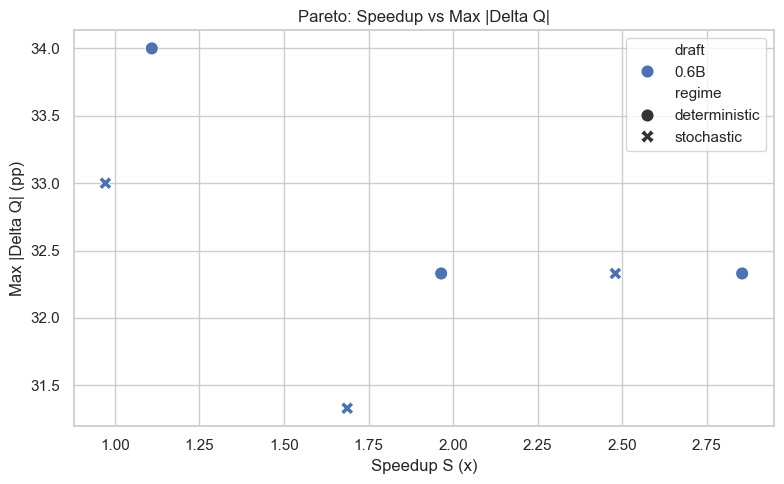

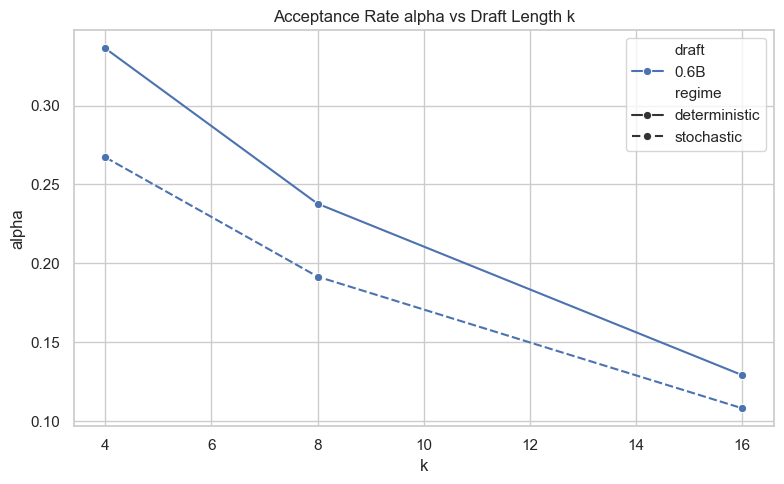

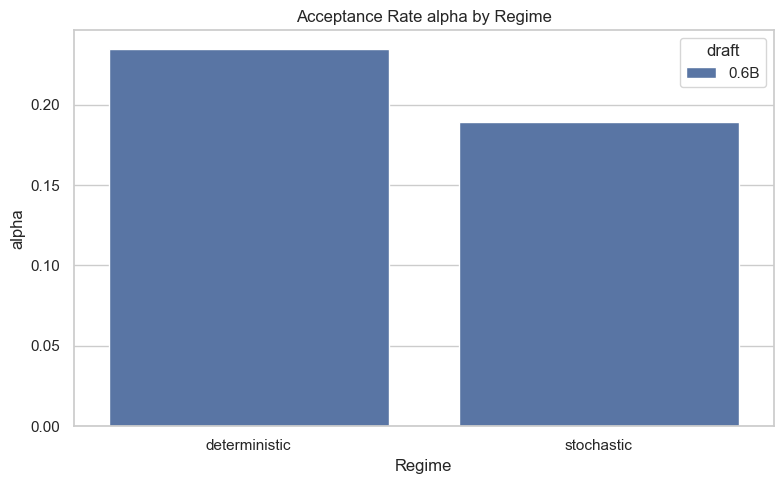

Saved figures:
  - C:\Working\speculative-decoding-main_v10\speculative-decoding-main\Review\figures\pareto_speedup_vs_quality_delta.png
  - C:\Working\speculative-decoding-main_v10\speculative-decoding-main\Review\figures\acceptance_vs_k.png
  - C:\Working\speculative-decoding-main_v10\speculative-decoding-main\Review\figures\acceptance_by_regime.png


In [19]:
import os
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd.parent.parent]
project_root = None
for c in candidates:
    if (c / "src").exists() and (c / "experiment.ipynb").exists():
        project_root = c
        break
if project_root is None:
    project_root = cwd

SRC_DIR = str(project_root / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

os.environ["SPECDEC_HF_OFFLINE_FIRST"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import matplotlib.pyplot as plt
import seaborn as sns
from runtime import bootstrap_notebook, ensure_df_all

bootstrap_notebook()

if "df_all" not in globals() or df_all.empty:
    df_all = ensure_df_all(globals())
if "stability_results" not in globals():
    stability_results = {}

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

df_plot = df_all.copy()
delta_cols = [c for c in df_plot.columns if c.startswith("delta_")]
if not delta_cols:
    delta_cols = [c for c in df_plot.columns if c.startswith("dQ_")]

df_plot["max_abs_delta"] = df_plot[delta_cols].abs().max(axis=1) if delta_cols else 0.0

# Pareto scatter: Speedup vs max quality drift
plt.figure(figsize=(8, 5))
ax = sns.scatterplot(
    data=df_plot,
    x="S",
    y="max_abs_delta",
    hue="draft",
    style="regime",
    s=90,
)
ax.set_title("Pareto: Speedup vs Max |Delta Q|")
ax.set_xlabel("Speedup S (x)")
ax.set_ylabel("Max |Delta Q| (pp)")
plt.tight_layout()
pareto_path = FIGURES_DIR / "pareto_speedup_vs_quality_delta.png"
plt.savefig(pareto_path, dpi=160)
plt.show()

# Acceptance vs k grouped by draft and regime
alpha_k = (
    df_plot.groupby(["draft", "regime", "k"], as_index=False)["alpha"]
    .mean()
)

plt.figure(figsize=(8, 5))
ax = sns.lineplot(data=alpha_k, x="k", y="alpha", hue="draft", style="regime", marker="o")
ax.set_title("Acceptance Rate alpha vs Draft Length k")
ax.set_xlabel("k")
ax.set_ylabel("alpha")
plt.tight_layout()
alpha_k_path = FIGURES_DIR / "acceptance_vs_k.png"
plt.savefig(alpha_k_path, dpi=160)
plt.show()

# Acceptance by regime (temperature proxy)
alpha_reg = (
    df_plot.groupby(["regime", "draft"], as_index=False)["alpha"]
    .mean()
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=alpha_reg, x="regime", y="alpha", hue="draft")
ax.set_title("Acceptance Rate alpha by Regime")
ax.set_xlabel("Regime")
ax.set_ylabel("alpha")
plt.tight_layout()
alpha_reg_path = FIGURES_DIR / "acceptance_by_regime.png"
plt.savefig(alpha_reg_path, dpi=160)
plt.show()

print("Saved figures:")
print(f"  - {pareto_path}")
print(f"  - {alpha_k_path}")
print(f"  - {alpha_reg_path}")


In [ ]:
# Synthesis tables for manuscript

results_matrix_cols = [
    "config", "draft", "k", "regime", "S", "alpha", "B_eff",
    "T_mean_s", "R_tok_mean", "TTFT_mean_ms", "TPOT_mean_ms",
    "gsm8k", "mmlu", "cnndm", "gpu_graph_mode", "gpu_graph_capture_rate",
]
results_matrix_cols = [c for c in results_matrix_cols if c in df_all.columns]

results_matrix = df_all[results_matrix_cols].sort_values(["draft", "k", "regime"]).copy()
display(results_matrix)
results_matrix.to_csv(RESULTS_DIR / "table_full_results_matrix.csv", index=False)

# Best speculative config per task + baseline comparison
quality_table_rows = []
baseline_quality_map = {
    "deterministic": base_quality_det,
    "stochastic": base_quality_stoch,
}

for task in ["gsm8k", "mmlu", "cnndm"]:
    if task not in df_all.columns:
        continue
    best_idx = df_all[task].idxmax()
    best_row = df_all.loc[best_idx]
    regime = best_row["regime"]
    baseline_score = baseline_quality_map[regime][task]
    quality_table_rows.append({
        "task": task,
        "baseline_regime": regime,
        "baseline_score": baseline_score,
        "best_spec_config": best_row["config"],
        "best_spec_score": best_row[task],
        "delta_spec_minus_base": round(best_row[task] - baseline_score, 2),
    })

df_quality_compare = pd.DataFrame(quality_table_rows)
print("Best speculative config per task (vs matching baseline regime):")
display(df_quality_compare)
df_quality_compare.to_csv(RESULTS_DIR / "table_quality_comparison.csv", index=False)

print("Saved tables:")
print(f"  - {RESULTS_DIR / 'table_full_results_matrix.csv'}")
print(f"  - {RESULTS_DIR / 'table_quality_comparison.csv'}")

In [21]:
# Audit checklist: what is still missing for Phase 6 paper completion
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "sec").exists():
    # Fallback to notebook path root behavior if executed from elsewhere
    project_root = Path(SRC_DIR).parent

checks = []

# 1) Missing sections requested by execution plan
for rel in ["sec/01b_related_work.tex", "sec/06_results.tex"]:
    p = project_root / rel
    checks.append({
        "item": f"Section file exists: {rel}",
        "status": "PASS" if p.exists() else "MISSING",
        "evidence": str(p),
    })

# 2) Abstract placeholders still present?
abstract_path = project_root / "sec/00_abstract.tex"
if abstract_path.exists():
    abstract_text = abstract_path.read_text(encoding="utf-8", errors="ignore")
    placeholders_present = any(tok in abstract_text for tok in ["[X]", "[Y]", "[Z]"])
    checks.append({
        "item": "Abstract placeholders resolved ([X],[Y],[Z])",
        "status": "MISSING" if placeholders_present else "PASS",
        "evidence": "Placeholders found" if placeholders_present else "No placeholders found",
    })

# 3) Rejection-position instrumentation availability
has_verify_logs = any("verify_log" in row for cfg in all_spec_results.values() for row in cfg)
checks.append({
    "item": "Token-position rejection logs persisted",
    "status": "PASS" if has_verify_logs else "MISSING",
    "evidence": "verify_log present in result rows" if has_verify_logs else "verify_log dropped in run_speculative_grid output rows",
})

# 4) Visualization module implementation
viz_path = project_root / "src/visualize.py"
if viz_path.exists():
    viz_text = viz_path.read_text(encoding="utf-8", errors="ignore")
    stub = "implemented later" in viz_text.lower()
    checks.append({
        "item": "src/visualize.py implemented",
        "status": "MISSING" if stub else "PASS",
        "evidence": "Stub marker found" if stub else "No stub marker found",
    })

# 5) Ensure phase outputs written
required_outputs = [
    project_root / "results/all_configs_summary.csv",
    project_root / "results/all_configs_combined.csv",
    project_root / "results/table_full_results_matrix.csv",
    project_root / "results/table_quality_comparison.csv",
]
for out in required_outputs:
    checks.append({
        "item": f"Output generated: {out.name}",
        "status": "PASS" if out.exists() else "PENDING",
        "evidence": str(out),
    })

df_audit = pd.DataFrame(checks)
print("Phase 6 audit report:")
display(df_audit)

missing_items = df_audit[df_audit["status"].isin(["MISSING", "PENDING"])]
if missing_items.empty:
    print("\nAll checklist items passed.")
else:
    print("\nItems still pending/missing:")
    display(missing_items)

Phase 6 audit report:


,item,status,evidence
0,Section file exists: sec/01b_related_work.tex,PASS,C:\Working\speculative-decoding-main_v10\specu...
1,Section file exists: sec/06_results.tex,PASS,C:\Working\speculative-decoding-main_v10\specu...
2,"Abstract placeholders resolved ([X],[Y],[Z])",PASS,No placeholders found
3,Token-position rejection logs persisted,MISSING,verify_log dropped in run_speculative_grid out...
4,src/visualize.py implemented,PASS,No stub marker found
5,Output generated: all_configs_summary.csv,PENDING,C:\Working\speculative-decoding-main_v10\specu...
6,Output generated: all_configs_combined.csv,PENDING,C:\Working\speculative-decoding-main_v10\specu...
7,Output generated: table_full_results_matrix.csv,PENDING,C:\Working\speculative-decoding-main_v10\specu...
8,Output generated: table_quality_comparison.csv,PENDING,C:\Working\speculative-decoding-main_v10\specu...



Items still pending/missing:


,item,status,evidence
3,Token-position rejection logs persisted,MISSING,verify_log dropped in run_speculative_grid out...
5,Output generated: all_configs_summary.csv,PENDING,C:\Working\speculative-decoding-main_v10\specu...
6,Output generated: all_configs_combined.csv,PENDING,C:\Working\speculative-decoding-main_v10\specu...
7,Output generated: table_full_results_matrix.csv,PENDING,C:\Working\speculative-decoding-main_v10\specu...
8,Output generated: table_quality_comparison.csv,PENDING,C:\Working\speculative-decoding-main_v10\specu...


## Phase 7 -- ACSD: Adaptive Cascaded Speculative Decoding

**Design note:** ACSD's primary and rescue drafters are both the same real Qwen3-0.6B model in this study (see `ACSD_EVAL` patched in Cell 2) -- there is no separate smaller/larger draft pair available for Qwen3 here. The cascaded-drafter mechanism (switch to rescue drafter when acceptance collapses, then back to primary when stable) is exercised with primary == rescue, so its systems behavior (switching logic, fallback triggers) is still tested even though there is currently no capacity difference between the two roles.


In [ ]:
# --- Phase 7: ACSD setup (target + primary/rescue drafts) ---
import os
import sys
import gc
from pathlib import Path

import torch

cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents]
project_root = next((p for p in candidates if (p / "src").exists()), None)
assert project_root is not None, "Could not locate project root containing src/"
src_path = str(project_root / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from config import ACSD_EVAL, TARGET_MODEL_ID, DRAFT_MODELS, TARGET_QUANT, DRAFT_QUANT
from runtime import bootstrap_notebook, ensure_data
from speculative import load_model_on_device

bootstrap_notebook()

for name in ("drifter_model", "drifter_schedule", "draft_gridB_model", "draft_gridB_tokenizer", "draft_gridA_model", "draft_gridA_tokenizer"):
    if name in globals():
        del globals()[name]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

data = ensure_data(globals())

FORCE_SINGLE_GPU = True
RUN_DEVICE = "cuda:0"

if FORCE_SINGLE_GPU and not torch.cuda.is_available():
    raise RuntimeError("FORCE_SINGLE_GPU=True but CUDA is unavailable")

primary_label = ACSD_EVAL["primary_draft"]
rescue_label = ACSD_EVAL["rescue_draft"]

if FORCE_SINGLE_GPU:
    target_model, target_tokenizer = load_model_on_device(
        TARGET_MODEL_ID, RUN_DEVICE, TARGET_QUANT
    )
    draft_primary_model, _ = load_model_on_device(
        DRAFT_MODELS[primary_label], RUN_DEVICE, DRAFT_QUANT
    )
    draft_rescue_model, _ = load_model_on_device(
        DRAFT_MODELS[rescue_label], RUN_DEVICE, DRAFT_QUANT
    )
else:
    from runtime import ensure_target_model, ensure_draft_model
    target_model, target_tokenizer = ensure_target_model(globals())
    draft_primary_model, _ = ensure_draft_model(globals(), primary_label)
    draft_rescue_model, _ = ensure_draft_model(globals(), rescue_label)

globals()["target_model"] = target_model
globals()["target_tokenizer"] = target_tokenizer
globals()["draft_primary_model"] = draft_primary_model
globals()["draft_rescue_model"] = draft_rescue_model

print(f"Target model: {TARGET_MODEL_ID}")
print(f"Primary draft: {primary_label}")
print(f"Rescue draft:  {rescue_label}")
print(f"ACSD k choices: {ACSD_EVAL['k_choices']} (base={ACSD_EVAL['base_k']})")
print(f"ACSD regimes: {ACSD_EVAL['regimes']}")

def _model_device_summary(model, name):
    hf_map = getattr(model, "hf_device_map", None)
    if isinstance(hf_map, dict):
        devices = sorted({str(v) for v in hf_map.values()})
        has_cpu = any(str(v).startswith("cpu") for v in devices)
        has_disk = any(str(v).startswith("disk") for v in devices)
    else:
        devices = [str(next(model.parameters()).device)]
        has_cpu = False
        has_disk = False
    print(f"{name} devices: {devices}")
    if has_cpu or has_disk:
        print(f"WARNING: {name} has CPU/disk offload; ACSD can be much slower.")
    return devices

target_devices = _model_device_summary(target_model, "target")
primary_devices = _model_device_summary(draft_primary_model, f"draft_{primary_label}")
rescue_devices = _model_device_summary(draft_rescue_model, f"draft_{rescue_label}")

same_single_cuda_all = (
    len(target_devices) == 1 and target_devices[0].startswith("cuda")
    and len(primary_devices) == 1 and primary_devices[0] == target_devices[0]
    and len(rescue_devices) == 1 and rescue_devices[0] == target_devices[0]
    )
print(f"same_single_cuda_all={same_single_cuda_all}")
if FORCE_SINGLE_GPU and not same_single_cuda_all:
    raise RuntimeError("FORCE_SINGLE_GPU is enabled, but ACSD models are not all on one CUDA device.")


In [ ]:
# --- Phase 7: run ACSD over full evaluation manifests ---
import gc
import importlib
import os
import time
from datetime import datetime, timedelta

import torch
from tqdm.auto import tqdm

from config import ACSD_EVAL
import acsd as acsd_module

acsd_module = importlib.reload(acsd_module)
run_acsd_grid = acsd_module.run_acsd_grid

DEBUG_ACSD_FAIL_FAST = True
if DEBUG_ACSD_FAIL_FAST:
    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
    print("Debug mode: CUDA_LAUNCH_BLOCKING=1 (ACSD)")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

draft_models = {
    ACSD_EVAL["primary_draft"]: draft_primary_model,
    ACSD_EVAL["rescue_draft"]: draft_rescue_model,
}

regimes = tuple(ACSD_EVAL["regimes"])
samples_per_cfg = sum(len(v) for v in data.values())
total_cfg = len(regimes)
total_samples_all = samples_per_cfg * total_cfg
done_samples = [0]
started_at = time.perf_counter()

bar = tqdm(
    total=total_samples_all,
    desc="acsd samples",
    dynamic_ncols=True,
    leave=True,
    mininterval=0.2,
    bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]",
)

def _eta_text(done_n: int, total_n: int) -> tuple[float, str]:
    if done_n <= 0 or done_n >= total_n:
        return 0.0, "--:--:--"
    elapsed_s = time.perf_counter() - started_at
    remaining_s = max((elapsed_s / done_n) * (total_n - done_n), 0.0)
    eta_clock = (datetime.now() + timedelta(seconds=remaining_s)).strftime("%H:%M:%S")
    return remaining_s, eta_clock

acsd_results = globals().get("acsd_results", {})

try:
    for cfg_idx, regime in enumerate(regimes, start=1):
        regime_short = "det" if regime == "deterministic" else "stoch"
        cfg_started_at = time.perf_counter()

        def _on_sample(event):
            prev = done_samples[0]
            now = prev + 1
            done_samples[0] = now
            bar.update(1)
            remaining_s, eta_clock = _eta_text(done_samples[0], total_samples_all)
            bar.set_postfix_str(
                f"cfg {cfg_idx}/{total_cfg} regime={regime_short} | sample {done_samples[0]}/{total_samples_all} | rem={remaining_s/60:.1f}m | eta={eta_clock}"
            )

        try:
            rows = run_acsd_grid(
                data=data,
                regime_name=regime,
                target_model=target_model,
                target_tokenizer=target_tokenizer,
                draft_models=draft_models,
                primary_label=ACSD_EVAL["primary_draft"],
                rescue_label=ACSD_EVAL["rescue_draft"],
                base_k=ACSD_EVAL["base_k"],
                k_choices=tuple(ACSD_EVAL["k_choices"]),
                label="acsd",
                checkpoint_every=ACSD_EVAL.get("checkpoint_every", 50),
                progress_callback=_on_sample,
                accept_window=ACSD_EVAL["accept_window"],
                k_low_threshold=ACSD_EVAL["k_low_threshold"],
                k_high_threshold=ACSD_EVAL["k_high_threshold"],
                rescue_trigger_alpha=ACSD_EVAL["rescue_trigger_alpha"],
                rescue_trigger_consecutive=ACSD_EVAL["rescue_trigger_consecutive"],
                rescue_hold_steps=ACSD_EVAL["rescue_hold_steps"],
                rescue_cooldown_steps=ACSD_EVAL.get("rescue_cooldown_steps", 8),
                ar_fallback_alpha=ACSD_EVAL["ar_fallback_alpha"],
                ar_fallback_min_tokens=ACSD_EVAL["ar_fallback_min_tokens"],
                ar_fallback_consecutive=ACSD_EVAL.get("ar_fallback_consecutive", 3),
            )
        except Exception as e:
            print("\n[FAIL] ACSD execution failed")
            print(f"  regime={regime}")
            print(f"  type={type(e).__name__}")
            print(f"  message={e}")
            raise

        key = f"acsd_{ACSD_EVAL['primary_draft']}_to_{ACSD_EVAL['rescue_draft']}_{regime}"
        acsd_results[key] = rows

        cfg_elapsed = time.perf_counter() - cfg_started_at
        remaining_s, eta_clock = _eta_text(done_samples[0], total_samples_all)
        bar.set_postfix_str(
            f"cfg {cfg_idx}/{total_cfg} done regime={regime_short} | cfg={cfg_elapsed:.1f}s | sample {done_samples[0]}/{total_samples_all} | rem={remaining_s/60:.1f}m | eta={eta_clock}"
        )
finally:
    bar.close()

globals()["acsd_results"] = acsd_results

print(f"ACSD configs processed: {len(acsd_results)}")
for key, rows in acsd_results.items():
    print(f"  {key}: {len(rows)} samples")

Debug mode: CUDA_LAUNCH_BLOCKING=1 (ACSD)


acsd samples:   0%|          | 0/2000 [00:00<?, ?it/s]

In [ ]:
# --- Phase 8: ACSD metrics + head-to-head comparison vs AR best ---
import pandas as pd

from metrics import (
    compute_acceptance_metrics,
    compute_latency_metrics,
    compute_speedup,
    compute_quality_delta,
)
from evaluate import evaluate_results
from config import RESULTS_DIR, ACSD_EVAL

baseline_results = globals().get("baseline_results", {})
baseline_det_rows = baseline_results.get("deterministic", [])
if not baseline_det_rows:
    baseline_det_rows = globals().get("baseline_det", [])

data = globals().get("data")
if data is None:
    from runtime import ensure_data
    data = ensure_data(globals())

acsd_summary = []
for key, rows in acsd_results.items():
    regime = key.split("_")[-1]
    accept = compute_acceptance_metrics(rows)
    latency = compute_latency_metrics(rows)
    quality = evaluate_results(rows, data)

    if baseline_det_rows:
        base_qual = evaluate_results(baseline_det_rows, data)
        speedup = compute_speedup(baseline_det_rows, rows)
        delta_q = compute_quality_delta(base_qual, quality)
    else:
        speedup = 0.0
        delta_q = {}

    df_rows = pd.DataFrame(rows)
    rescue_steps_mean = float(df_rows["acsd_rescue_steps"].mean()) if "acsd_rescue_steps" in df_rows.columns else 0.0
    fallback_rate = float(df_rows["acsd_used_ar_fallback"].mean()) if "acsd_used_ar_fallback" in df_rows.columns else 0.0
    if 'gpu_graph_capture' in df_rows.columns and not df_rows.empty:
        graph_mode = str(df_rows['gpu_graph_capture'].mode().iloc[0])
        graph_capture_rate = float((df_rows['gpu_graph_capture'] == 'captured').mean())
    else:
        graph_mode = 'n/a'
        graph_capture_rate = 0.0

    acsd_summary.append({
        "config": f"ACSD-{regime}",
        "draft": "ACSD",
        "regime": regime,
        "primary_draft": ACSD_EVAL["primary_draft"],
        "rescue_draft": ACSD_EVAL["rescue_draft"],
        "base_k": ACSD_EVAL["base_k"],
        "alpha": accept.get("alpha"),
        "B_eff": accept.get("B_eff"),
        "tokens_per_sec": latency.get("R_tok_mean"),
        "speedup": speedup,
        "mean_rescue_steps": round(rescue_steps_mean, 3),
        "fallback_rate": round(fallback_rate, 4),
        "gpu_graph_mode": graph_mode,
        "gpu_graph_capture_rate": round(graph_capture_rate, 4),
        **{f"quality_{k_}": v for k_, v in quality.items()},
        **{f"delta_{k_}": v for k_, v in delta_q.items()},
    })

df_acsd = pd.DataFrame(acsd_summary).sort_values(["regime"]).reset_index(drop=True)
print("ACSD summary:")
display(df_acsd)

df_all = globals().get("df_all")
if df_all is not None and not df_all.empty:
    ar_det = df_all[df_all["regime"] == "deterministic"].copy()
    ar_best = ar_det.sort_values("S", ascending=False).head(3)
    acsd_best = df_acsd.sort_values("speedup", ascending=False).head(3)
    print("\nTop-3 AR (deterministic):")
    display(ar_best[["config", "draft", "k", "alpha", "B_eff", "R_tok_mean", "S"]])
    print("\nTop ACSD configs:")
    display(acsd_best[["config", "regime", "alpha", "B_eff", "tokens_per_sec", "speedup", "mean_rescue_steps", "fallback_rate", "gpu_graph_mode", "gpu_graph_capture_rate"]])

df_acsd.to_csv(RESULTS_DIR / "acsd_summary.csv", index=False)
print(f"\nSaved -> {RESULTS_DIR / 'acsd_summary.csv'}")

### Transition: Phase 7 → Phase 8

Phase 7 executes ACSD decoding runs. Phase 8 consolidates ACSD metrics and
compares them against the AR speculative baseline under the same manifests and
evaluation protocol.

## Summary

Display the final results matrix for baseline + AR speculative runs, together
with ACSD Phase 7/8 outcomes and stability info from Phase 4b.

In [ ]:
# Final summary table
print("=" * 80)
print("EXPERIMENT COMPLETE — FULL RESULTS MATRIX")
print("=" * 80)

display_cols = [c for c in ["config", "draft", "k", "regime", "S", "alpha", "B_eff",
                "T_mean_s", "R_tok_mean", "TTFT_mean_ms", "TPOT_mean_ms",
                "gpu_graph_mode", "gpu_graph_capture_rate"] if c in df_all.columns]

print("\n--- Latency & Throughput ---")
display(df_all[display_cols].sort_values("R_tok_mean", ascending=False))

quality_cols = [c for c in df_all.columns if c in ["gsm8k", "mmlu", "cnndm"]]
if quality_cols:
    print("\n--- Quality (%) ---")
    display(df_all[["config"] + quality_cols])

# Best config under quality constraint
if not df_qualified.empty:
    best = df_qualified.loc[df_qualified["S"].idxmax()]
    print(f"\n★ Best config (|ΔQ| ≤ 1.0): {best['config']}")
    print(f"  Speedup: {best['S']:.2f}x, α: {best['alpha']:.3f}")

# Save combined table
df_all.to_csv(RESULTS_DIR / "all_configs_combined.csv", index=False)
print(f"\nSaved → {RESULTS_DIR / 'all_configs_combined.csv'}")

# Stability
if stability_results:
    print("\n--- Stability (σ_S) ---")
    for cfg, info in stability_results.items():
        print(f"  {cfg}: σ_S = {info['sigma_S']:.4f}, seeds = {info['speedups']}")